# Figure 2 Melanoma Neighborhood Tutorial
Updated annotations: 2026-03-27 (America/New_York).

This workflow reads melanoma cell-level annotations, constructs k-nearest-neighbor composition windows, estimates neighborhood probabilities with MINGL, and then interprets multi-neighborhood or border-like cells across the main and supplemental analyses. The annotations below reference the package implementations in `src/mingl/pp`, `src/mingl/tl`, and `src/mingl/pl` so that users can see which parameters are stable defaults and which are meant to be customized for a new dataset.


### Step 1. Import the analysis stack
Purpose: Load the AnnData, plotting, statistics, and `mingle-hl` package imported as `mingl` used throughout the tutorial.

User-adjustable inputs: You can usually keep these imports as-is. If you are adapting the notebook to a minimal environment, the main requirement is that `mingle-hl` and its plotting dependencies are installed, then imported as `mingl`.

Expected output: The Python session is ready to read spatial data, compute probabilities, and generate figures.

In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import mingl as mg
import tqdm

### Step 2. Load the curated neighborhood assignment table
Purpose: Read the melanoma neighborhood assignment file with `mg.pp.read_file` from `src/mingl/pp/preprocessing.py`. That loader accepts either `.csv` or `.h5ad` inputs and stores `.csv` columns in `adata.obs`.

User-adjustable inputs: Change `file_path` to your own cell-level neighborhood table. The file must contain the columns that will later be referenced for coordinates, region identifiers, cell types, and neighborhood labels.

Expected output: `cells` becomes the working AnnData object used for neighborhood modeling and all downstream figures.

In [2]:
file_path = r"Z:\MINGLE\Data\Melanoma\23_10_11_Melanoma_Marker_Cell_Neighborhood.csv"
cells = mg.pp.read_file(file_path)

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


### Step 5. Inspect the modeling dataset
Purpose: Check that the neighborhood assignment table has the fields required by the MINGL pipeline, especially coordinates, region labels, cell-type labels, and neighborhood calls.

User-adjustable inputs: No arguments are changed here; use this inspection to decide whether `X`, `Y`, `cluster_col`, `neighborhood_col`, or `region_key` need to be renamed.

Expected output: A preview of `cells.obs` showing the exact columns that will be consumed downstream.

In [5]:
cells.obs

,Unnamed: 0,CCR7,CD103,CD11b,CD11c,CD138,CD15,CD163,CD20,CD206,...,Cell_Type_Common,Cell_Type_Sub,CD38,filename,region,x,y,Cell_Type,Overall_Cell_Type,Neighborhood
0,0,-0.362926,-0.729925,-0.150820,-0.363121,-0.193573,-0.376392,-0.277710,-0.096556,-0.326673,...,Stromal,CD73+ Stromal,NaN,21_06_23_reg001.tsv,2,3981,47146,CD73+ Stromal,Stromal,Stromal Enriched
1,1,-0.542319,-0.723530,-0.193650,-0.359325,-0.199382,-0.394698,-0.219857,-0.126534,-0.333797,...,Stromal,CD73+ Stromal,NaN,21_06_23_reg001.tsv,2,5286,39373,CD73+ Stromal,Stromal,Stromal Enriched
2,2,-0.444684,-0.497128,-0.329550,-0.292091,-0.201171,-0.202878,-0.309667,-0.135984,-0.347450,...,Endothelial,Endothelial,NaN,21_06_23_reg001.tsv,2,22899,42306,Endothelial,Stromal,Vasculature
3,3,-0.829088,-1.629941,-0.341772,-0.380618,-0.255592,-0.419650,-0.115570,-0.118611,0.245775,...,Stromal,CD73+ Stromal,NaN,21_06_23_reg001.tsv,2,5747,45479,CD73+ Stromal,Stromal,Stromal Enriched
4,4,0.111211,-0.134976,3.659562,0.540194,-0.181382,5.446553,-0.212632,-0.125781,-0.246451,...,Neutrophil,Neutrophil,NaN,21_06_23_reg001.tsv,2,17460,49393,Neutrophil,Immune,Neutrophil Enriched
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,5019154,0.098215,-0.083622,-0.217149,-0.437058,-0.297181,-0.058682,-0.292474,-0.041080,-0.335148,...,Stromal,Stromal,-0.723163,23_07_06_reg002.tsv,2,4283,6987,Stromal,Stromal,Proliferating Tumor
5019155,5019155,-0.240248,-0.113821,-0.464631,-0.433815,-0.275257,-0.066953,-0.282331,-0.028372,-0.194535,...,Tumor,Tumor,-0.350178,23_07_06_reg002.tsv,2,17172,6095,MelanA+ Tumor,Tumor,Stromal Enriched
5019156,5019156,-0.423292,-0.166772,-0.623979,-0.435652,-0.300200,-0.055559,-0.314097,-0.139452,-0.301023,...,Stromal,Stromal,-0.099238,23_07_06_reg002.tsv,2,16878,4870,Stromal,Stromal,Stromal Enriched
5019157,5019157,1.402914,0.407268,1.345068,-0.353550,-0.301476,-0.048187,1.235023,-0.134024,0.436833,...,Tumor,Tumor,-0.057958,23_07_06_reg002.tsv,2,13326,10841,Tumor,Tumor,Macrophage Enriched Immune


### Step 6. Define the key column names used throughout the workflow
Purpose: Standardize the coordinate, cell-type, neighborhood, and region columns once so the same names can be passed consistently into the `mg.tl` and `mg.pl` functions.

User-adjustable inputs: Update `X`, `Y`, `cluster_col`, `neighborhood_col`, `region_key`, and `keep_cols` if your dataset uses different schema names. `keep_cols` controls which metadata are carried into the KNN window tables returned by `mg.tl.KNN2`.

Expected output: A reusable parameter block that keeps later function calls readable and easy to adapt.

In [6]:
X = 'x'                  
Y = 'y'     
cluster_col = "Cell_Type"
neighborhood_col = "Neighborhood"
region_key = "filename"
keep_cols = [X, Y, region_key, cluster_col]

### Step 7. Confirm the cell-type vocabulary
Purpose: List the unique values in the cell-type column before building windows or centroids. This is especially important because the centroid and GMM steps create per-cell-type features from this vocabulary.

User-adjustable inputs: If the output looks unexpectedly fragmented, harmonize labels upstream before continuing.

Expected output: A compact list of the cell types that will define the neighborhood feature space.

In [7]:
cells.obs[cluster_col].unique()

array(['CD73+ Stromal', 'Endothelial', 'Neutrophil', 'DC',
       'FAP+ Fibroblast', 'CD163+ CD206+ Macrophage', 'Stromal',
       'CD56+ Tumor', 'Smooth Muscle', 'Epithelial', 'CD8+ T',
       'CD68+ Macrophage', 'CD4+ T', 'CD4+ Treg', 'GZMB+ CD8+ T',
       'TCF1/7+ CD8+ T', 'GZMB+ PD1+ CD8+ T', 'PD1+ CD8+ T',
       'PD1+ TCF1/7+ CD8+ T', 'GZMB+ TCF1/7+ CD8+ T',
       'GZMB+ TCF1/7+ PD1+ CD8+ T', 'NK', 'Nerve', 'Tumor',
       'MelanA+ Tumor', 'SOX10/S100+ Tumor', 'PTEN+ Tumor', 'FAP+ Tumor',
       'LDHA+ Tumor', 'MHCI+ Tumor', 'MHCI+ PDL1+ Tumor', 'EZH2+ Tumor',
       'EZH2+ Ki67+ Tumor', 'PDL1+ CD56+ Tumor', 'Bcatenin+ Tumor',
       'PDPN+ Stromal', 'B', 'FDCs', 'LDHA+ SOX10/S100+ Tumor'],
      dtype=object)

### Step 8. Recheck the full observation table
Purpose: Take one more broad look at the imported table after key assignment so you can verify that the analysis columns and metadata columns align.

User-adjustable inputs: No arguments change here; use the preview as a final pre-modeling sanity check.

Expected output: A complete `obs` preview that helps catch missing values or naming drift early.

In [8]:
cells.obs

,Unnamed: 0,CCR7,CD103,CD11b,CD11c,CD138,CD15,CD163,CD20,CD206,...,Cell_Type_Common,Cell_Type_Sub,CD38,filename,region,x,y,Cell_Type,Overall_Cell_Type,Neighborhood
0,0,-0.362926,-0.729925,-0.150820,-0.363121,-0.193573,-0.376392,-0.277710,-0.096556,-0.326673,...,Stromal,CD73+ Stromal,NaN,21_06_23_reg001.tsv,2,3981,47146,CD73+ Stromal,Stromal,Stromal Enriched
1,1,-0.542319,-0.723530,-0.193650,-0.359325,-0.199382,-0.394698,-0.219857,-0.126534,-0.333797,...,Stromal,CD73+ Stromal,NaN,21_06_23_reg001.tsv,2,5286,39373,CD73+ Stromal,Stromal,Stromal Enriched
2,2,-0.444684,-0.497128,-0.329550,-0.292091,-0.201171,-0.202878,-0.309667,-0.135984,-0.347450,...,Endothelial,Endothelial,NaN,21_06_23_reg001.tsv,2,22899,42306,Endothelial,Stromal,Vasculature
3,3,-0.829088,-1.629941,-0.341772,-0.380618,-0.255592,-0.419650,-0.115570,-0.118611,0.245775,...,Stromal,CD73+ Stromal,NaN,21_06_23_reg001.tsv,2,5747,45479,CD73+ Stromal,Stromal,Stromal Enriched
4,4,0.111211,-0.134976,3.659562,0.540194,-0.181382,5.446553,-0.212632,-0.125781,-0.246451,...,Neutrophil,Neutrophil,NaN,21_06_23_reg001.tsv,2,17460,49393,Neutrophil,Immune,Neutrophil Enriched
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,5019154,0.098215,-0.083622,-0.217149,-0.437058,-0.297181,-0.058682,-0.292474,-0.041080,-0.335148,...,Stromal,Stromal,-0.723163,23_07_06_reg002.tsv,2,4283,6987,Stromal,Stromal,Proliferating Tumor
5019155,5019155,-0.240248,-0.113821,-0.464631,-0.433815,-0.275257,-0.066953,-0.282331,-0.028372,-0.194535,...,Tumor,Tumor,-0.350178,23_07_06_reg002.tsv,2,17172,6095,MelanA+ Tumor,Tumor,Stromal Enriched
5019156,5019156,-0.423292,-0.166772,-0.623979,-0.435652,-0.300200,-0.055559,-0.314097,-0.139452,-0.301023,...,Stromal,Stromal,-0.099238,23_07_06_reg002.tsv,2,16878,4870,Stromal,Stromal,Stromal Enriched
5019157,5019157,1.402914,0.407268,1.345068,-0.353550,-0.301476,-0.048187,1.235023,-0.134024,0.436833,...,Tumor,Tumor,-0.057958,23_07_06_reg002.tsv,2,13326,10841,Tumor,Tumor,Macrophage Enriched Immune


### Step 9. Build k-nearest-neighbor composition windows
Purpose: Run `mg.tl.KNN2` from `src/mingl/tl/knn2.py` to summarize the local cell-type composition around each cell within each region.

User-adjustable inputs: Key adjustable inputs are `x_key`, `y_key`, `region_key`, `cluster_col`, `ks`, and `keep_obs_cols`. This notebook keeps the default coordinate keys (`x` and `y`) and requests the default set of neighborhood sizes while preserving selected metadata columns.

Expected output: `windows` is a dictionary mapping each requested `k` to a DataFrame of per-cell neighborhood composition counts.

In [9]:
windows = mg.tl.KNN2(cells, region_key=region_key, cluster_col=cluster_col, keep_obs_cols=keep_cols)


Example dummy cols: ['Cell_Type__B', 'Cell_Type__Bcatenin+ Tumor', 'Cell_Type__CD163+ CD206+ Macrophage', 'Cell_Type__CD4+ T', 'Cell_Type__CD4+ Treg']


### Step 10. Select the working neighborhood size
Purpose: Choose one `k` from the dictionary returned by `KNN2` and attach the original cell-type labels back onto that table so it is easier to inspect and reuse.

User-adjustable inputs: Change `k` to any value present in `windows`. Larger `k` smooths over a broader spatial context, while smaller `k` emphasizes more local structure.

Expected output: `windows2` becomes the working neighborhood-composition table for the rest of the notebook.

In [10]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2 = windows[k]
#Add cell type column to output windows dataframe
windows2[cluster_col] = cells.obs[cluster_col]

### Step 11. Inspect a representative neighborhood feature
Purpose: Look at one example column from `windows2` to see the local count structure that will later feed into centroid estimation and GMM scoring.

User-adjustable inputs: Swap in any cell-type column of interest if you want to inspect a different biological compartment.

Expected output: A single feature vector that makes the neighborhood-window output easier to interpret.

In [11]:
windows2["CD73+ Stromal"]

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


0          8.0
1          4.0
2          0.0
3          9.0
4          0.0
          ... 
5019154    3.0
5019155    2.0
5019156    1.0
5019157    1.0
5019158    0.0
Name: CD73+ Stromal, Length: 5019159, dtype: float16

### Step 12. Compute neighborhood centroids
Purpose: Use `mg.tl.centroid_Calculation` from `src/mingl/tl/centroids.py` to summarize the mean and standard deviation of each cell-type count within each annotated neighborhood.

User-adjustable inputs: Important parameters are `k`, `cluster_col`, `neighborhood_col`, `region_col`, and optional `store_key`. If you want centroid features based on a different neighborhood size than the default, set `k` explicitly here.

Expected output: `centroids` is an AnnData object whose rows are neighborhoods and whose variables are `<cell_type>_mean` and `<cell_type>_std` features.

In [12]:
centroids = mg.tl.centroid_Calculation(cells, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_col=region_key)

Example dummy cols: ['Cell_Type__B', 'Cell_Type__Bcatenin+ Tumor', 'Cell_Type__CD163+ CD206+ Macrophage', 'Cell_Type__CD4+ T', 'Cell_Type__CD4+ Treg']


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


{5:              x      y             filename        Cell_Type    B  \
0         3981  47146  21_06_23_reg001.tsv    CD73+ Stromal  0.0   
1         5286  39373  21_06_23_reg001.tsv    CD73+ Stromal  0.0   
2        22899  42306  21_06_23_reg001.tsv      Endothelial  0.0   
3         5747  45479  21_06_23_reg001.tsv    CD73+ Stromal  0.0   
4        17460  49393  21_06_23_reg001.tsv       Neutrophil  0.0   
...        ...    ...                  ...              ...  ...   
5019154   4283   6987  23_07_06_reg002.tsv          Stromal  0.0   
5019155  17172   6095  23_07_06_reg002.tsv    MelanA+ Tumor  0.0   
5019156  16878   4870  23_07_06_reg002.tsv          Stromal  0.0   
5019157  13326  10841  23_07_06_reg002.tsv            Tumor  0.0   
5019158   9977   2484  23_07_06_reg002.tsv  Bcatenin+ Tumor  0.0   

         Bcatenin+ Tumor  CD163+ CD206+ Macrophage  CD4+ T  CD4+ Treg  \
0                    0.0                       0.0     0.0        0.0   
1                    0.0         

### Step 13. Inspect the centroid matrix
Purpose: Preview `centroids.X` so you can confirm that the neighborhood centroid object contains the expected feature matrix before probabilistic scoring.

User-adjustable inputs: This is another QC checkpoint; if the matrix shape or value ranges look implausible, revisit the input labels or `k` choice.

Expected output: A numeric matrix of neighborhood-level mean and standard-deviation features.

In [13]:
centroids.X

array([[8.19361508e-01, 1.83882618e+00, 2.01236784e-01, ...,
        8.55438784e-03, 2.22161820e-04, 1.68772414e-02],
       [5.77596202e-02, 2.83591181e-01, 2.78734922e+00, ...,
        1.76094063e-02, 4.34216228e-04, 2.16674432e-02],
       [9.82441455e-02, 3.74229938e-01, 1.25112548e-01, ...,
        2.53528338e-02, 2.57267820e-04, 1.60376355e-02],
       ...,
       [1.05516069e-01, 4.01260197e-01, 7.72024214e-01, ...,
        7.07487157e-03, 1.75192705e-04, 1.32350447e-02],
       [1.00322261e-01, 3.95602077e-01, 3.15556407e-01, ...,
        3.00286729e-02, 7.77374778e-04, 2.78706364e-02],
       [5.66623695e-02, 2.74937838e-01, 2.15673000e-01, ...,
        3.04338094e-02, 1.83559384e-03, 4.53292355e-02]], shape=(16, 78))

### Step 14. Estimate neighborhood probabilities with the CPU GMM routine
Purpose: Run `mg.tl.cpu_gmm_probability` from `src/mingl/tl/gmm.py` to evaluate how well each cell's local composition matches every centroid profile.

User-adjustable inputs: The most important tunable inputs are `cluster_col`, `neighborhood_col`, `region_key`, `ks`, `k`, `threshold`, `num_processes`, `prob_key`, and `prob_variable_key`. Here the defaults are kept except for the schema keys.

Expected output: The probability matrix is stored in `cells.obsm['neighborhood_probabilities']`, and the corresponding neighborhood names are stored in `cells.uns['neighborhood_probability_neighborhoods']`.

In [ ]:
#mg.tl.cpu_gmm_probability(CELLS_ADATA=cells, CENTROIDS_ADATA=centroids, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_key=region_key)

Example dummy cols: ['Cell_Type__B', 'Cell_Type__Bcatenin+ Tumor', 'Cell_Type__CD163+ CD206+ Macrophage', 'Cell_Type__CD4+ T', 'Cell_Type__CD4+ Treg']
Using 14 processes.


/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprec

AnnData object with n_obs × n_vars = 5019159 × 0
    obs: 'Unnamed: 0', 'CCR7', 'CD103', 'CD11b', 'CD11c', 'CD138', 'CD15', 'CD163', 'CD20', 'CD206', 'CD21', 'CD25', 'CD3', 'CD31', 'CD4', 'CD45', 'CD45RA', 'CD45RO', 'CD56', 'CD57', 'CD68', 'CD73', 'CD8', 'CLEC9A', 'CXCL10', 'CXCL13', 'CXCL9', 'CXCR3', 'CXCR5', 'CollagenIV', 'EOMES', 'EZH2', 'FAP', 'FoxP3', 'GATA3', 'GranzymeB', 'HLA-DR', 'ICOS', 'IL10', 'IRF8', 'Ki67', 'LAG3', 'LDH-A', 'MHC-I', 'MMP9', 'Melan-A', 'PD-1', 'PD-L1', 'PTEN', 'Podoplanin', 'SOX10/S100', 'TCF1/7', 'Tbet', 'Vimentin', 'aSMA', 'bCatenin', 'pERK1/2', 'DAPI', 'cellid', 'donor', 'CCL5', 'Cell_Type_Common', 'Cell_Type_Sub', 'CD38', 'filename', 'region', 'x', 'y', 'Cell_Type', 'Overall_Cell_Type', 'Neighborhood'
    uns: 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

In [14]:
# GPU accelerated version of MINGL gmm

import mingl.tl.gmm_gpu as gpu_gmm

gpu_gmm.gpu_gmm_probability(cells, centroids, cluster_col= cluster_col, neighborhood_col= neighborhood_col, region_key= region_key, k= 10, 
                            batch_size= 20000, prob_key = 'neighborhood_probabilities', prob_variable_key = "neighborhood_probability_neighborhoods")

Example dummy cols: ['Cell_Type__B', 'Cell_Type__Bcatenin+ Tumor', 'Cell_Type__CD163+ CD206+ Macrophage', 'Cell_Type__CD4+ T', 'Cell_Type__CD4+ Treg']
GPU Processing batch 1/251...
GPU Processing batch 2/251...
GPU Processing batch 3/251...
GPU Processing batch 4/251...
GPU Processing batch 5/251...
GPU Processing batch 6/251...
GPU Processing batch 7/251...
GPU Processing batch 8/251...
GPU Processing batch 9/251...
GPU Processing batch 10/251...
GPU Processing batch 11/251...
GPU Processing batch 12/251...
GPU Processing batch 13/251...
GPU Processing batch 14/251...
GPU Processing batch 15/251...
GPU Processing batch 16/251...
GPU Processing batch 17/251...
GPU Processing batch 18/251...
GPU Processing batch 19/251...
GPU Processing batch 20/251...
GPU Processing batch 21/251...
GPU Processing batch 22/251...
GPU Processing batch 23/251...
GPU Processing batch 24/251...
GPU Processing batch 25/251...
GPU Processing batch 26/251...
GPU Processing batch 27/251...
GPU Processing batch 

AnnData object with n_obs × n_vars = 5019159 × 0
    obs: 'Unnamed: 0', 'CCR7', 'CD103', 'CD11b', 'CD11c', 'CD138', 'CD15', 'CD163', 'CD20', 'CD206', 'CD21', 'CD25', 'CD3', 'CD31', 'CD4', 'CD45', 'CD45RA', 'CD45RO', 'CD56', 'CD57', 'CD68', 'CD73', 'CD8', 'CLEC9A', 'CXCL10', 'CXCL13', 'CXCL9', 'CXCR3', 'CXCR5', 'CollagenIV', 'EOMES', 'EZH2', 'FAP', 'FoxP3', 'GATA3', 'GranzymeB', 'HLA-DR', 'ICOS', 'IL10', 'IRF8', 'Ki67', 'LAG3', 'LDH-A', 'MHC-I', 'MMP9', 'Melan-A', 'PD-1', 'PD-L1', 'PTEN', 'Podoplanin', 'SOX10/S100', 'TCF1/7', 'Tbet', 'Vimentin', 'aSMA', 'bCatenin', 'pERK1/2', 'DAPI', 'cellid', 'donor', 'CCL5', 'Cell_Type_Common', 'Cell_Type_Sub', 'CD38', 'filename', 'region', 'x', 'y', 'Cell_Type', 'Overall_Cell_Type', 'Neighborhood', 'Stromal Enriched', 'Vasculature', 'Neutrophil Enriched', 'Macrophage Enriched Immune', 'Vasculature & Immune', 'Productive T cell & Tumor', 'Proliferating Tumor', 'Inflamed Tumor', 'Tumor & Immune', 'Epithelial/Skin Appendages', 'Resting Tumor', 'PDPN+ St

### Step 15. Count how many neighborhoods each cell exceeds
Purpose: Apply `mg.tl.findPositives` from `src/mingl/tl/edges.py` to count the number of neighborhood probabilities above a chosen threshold for each cell.

User-adjustable inputs: You can tune `prob_key`, `threshold`, and `result_key`. A stricter threshold yields fewer multi-positive cells; a looser threshold makes border-like classifications more permissive.

Expected output: A new column named `Count_Above_Threshold` is added to `cells.obs`.

In [15]:
mg.tl.findPositives(cells)

AnnData object with n_obs × n_vars = 5019159 × 0
    obs: 'Unnamed: 0', 'CCR7', 'CD103', 'CD11b', 'CD11c', 'CD138', 'CD15', 'CD163', 'CD20', 'CD206', 'CD21', 'CD25', 'CD3', 'CD31', 'CD4', 'CD45', 'CD45RA', 'CD45RO', 'CD56', 'CD57', 'CD68', 'CD73', 'CD8', 'CLEC9A', 'CXCL10', 'CXCL13', 'CXCL9', 'CXCR3', 'CXCR5', 'CollagenIV', 'EOMES', 'EZH2', 'FAP', 'FoxP3', 'GATA3', 'GranzymeB', 'HLA-DR', 'ICOS', 'IL10', 'IRF8', 'Ki67', 'LAG3', 'LDH-A', 'MHC-I', 'MMP9', 'Melan-A', 'PD-1', 'PD-L1', 'PTEN', 'Podoplanin', 'SOX10/S100', 'TCF1/7', 'Tbet', 'Vimentin', 'aSMA', 'bCatenin', 'pERK1/2', 'DAPI', 'cellid', 'donor', 'CCL5', 'Cell_Type_Common', 'Cell_Type_Sub', 'CD38', 'filename', 'region', 'x', 'y', 'Cell_Type', 'Overall_Cell_Type', 'Neighborhood', 'Stromal Enriched', 'Vasculature', 'Neutrophil Enriched', 'Macrophage Enriched Immune', 'Vasculature & Immune', 'Productive T cell & Tumor', 'Proliferating Tumor', 'Inflamed Tumor', 'Tumor & Immune', 'Epithelial/Skin Appendages', 'Resting Tumor', 'PDPN+ St

### Step 16. Inspect the multi-positive count column
Purpose: Display the derived count column to confirm that the thresholding step produced reasonable values before you move into border-cell visualizations.

User-adjustable inputs: No parameters change here; use this preview to decide whether the threshold should be revisited.

Expected output: A per-cell series showing how many neighborhoods each cell exceeds.

In [16]:
cells.obs["Count_Above_Threshold"]

0          1
1          1
2          1
3          1
4          1
          ..
5019154    1
5019155    1
5019156    1
5019157    1
5019158    1
Name: Count_Above_Threshold, Length: 5019159, dtype: int64

### Step 17. Save the processed AnnData object
Purpose: Persist the modeled AnnData object after the expensive neighborhood-probability computation so later plotting blocks can be rerun quickly.

User-adjustable inputs: Change the filename or compression settings if you want the results saved elsewhere.

Expected output: A reusable `melanoma_results.h5ad` file containing the updated `obs`, `obsm`, and `uns` fields.

In [18]:
cells.write_h5ad(r"Z:\MINGLE\Reviewer Response\Code\R1.4\melanoma_results.h5ad", compression="gzip")

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\anndata\_io\utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


### Step 18. Reload the saved AnnData object
Purpose: Reopen the saved file to demonstrate that the workflow can resume from disk without recomputing the full GMM step.

User-adjustable inputs: Point to a different `.h5ad` file if you have already saved a processed result from a previous run.

Expected output: `cells` is repopulated from disk with the modeled neighborhood probabilities.

In [3]:
cells = ad.read_h5ad(r"Z:\MINGLE\Reviewer Response\Code\R1.4\melanoma_results.h5ad")

### Step 19. Plot positive-neighborhood probability distributions
Purpose: Call `mg.pl.edges_positive_probability` from `src/mingl/pl/edges_pp.py` to visualize the ranked probabilities for cells that are positive for one or more neighborhoods.

User-adjustable inputs: The most useful knobs are `prob_key`, `neighborhoods_to_loop`, `threshold`, `figsize`, `palette`, `legend`, `show`, and `save`. In this tutorial, the plot is displayed and exported as a PNG.

Expected output: A publication-style plot relating the number of positive neighborhoods per cell to the corresponding probability magnitude.

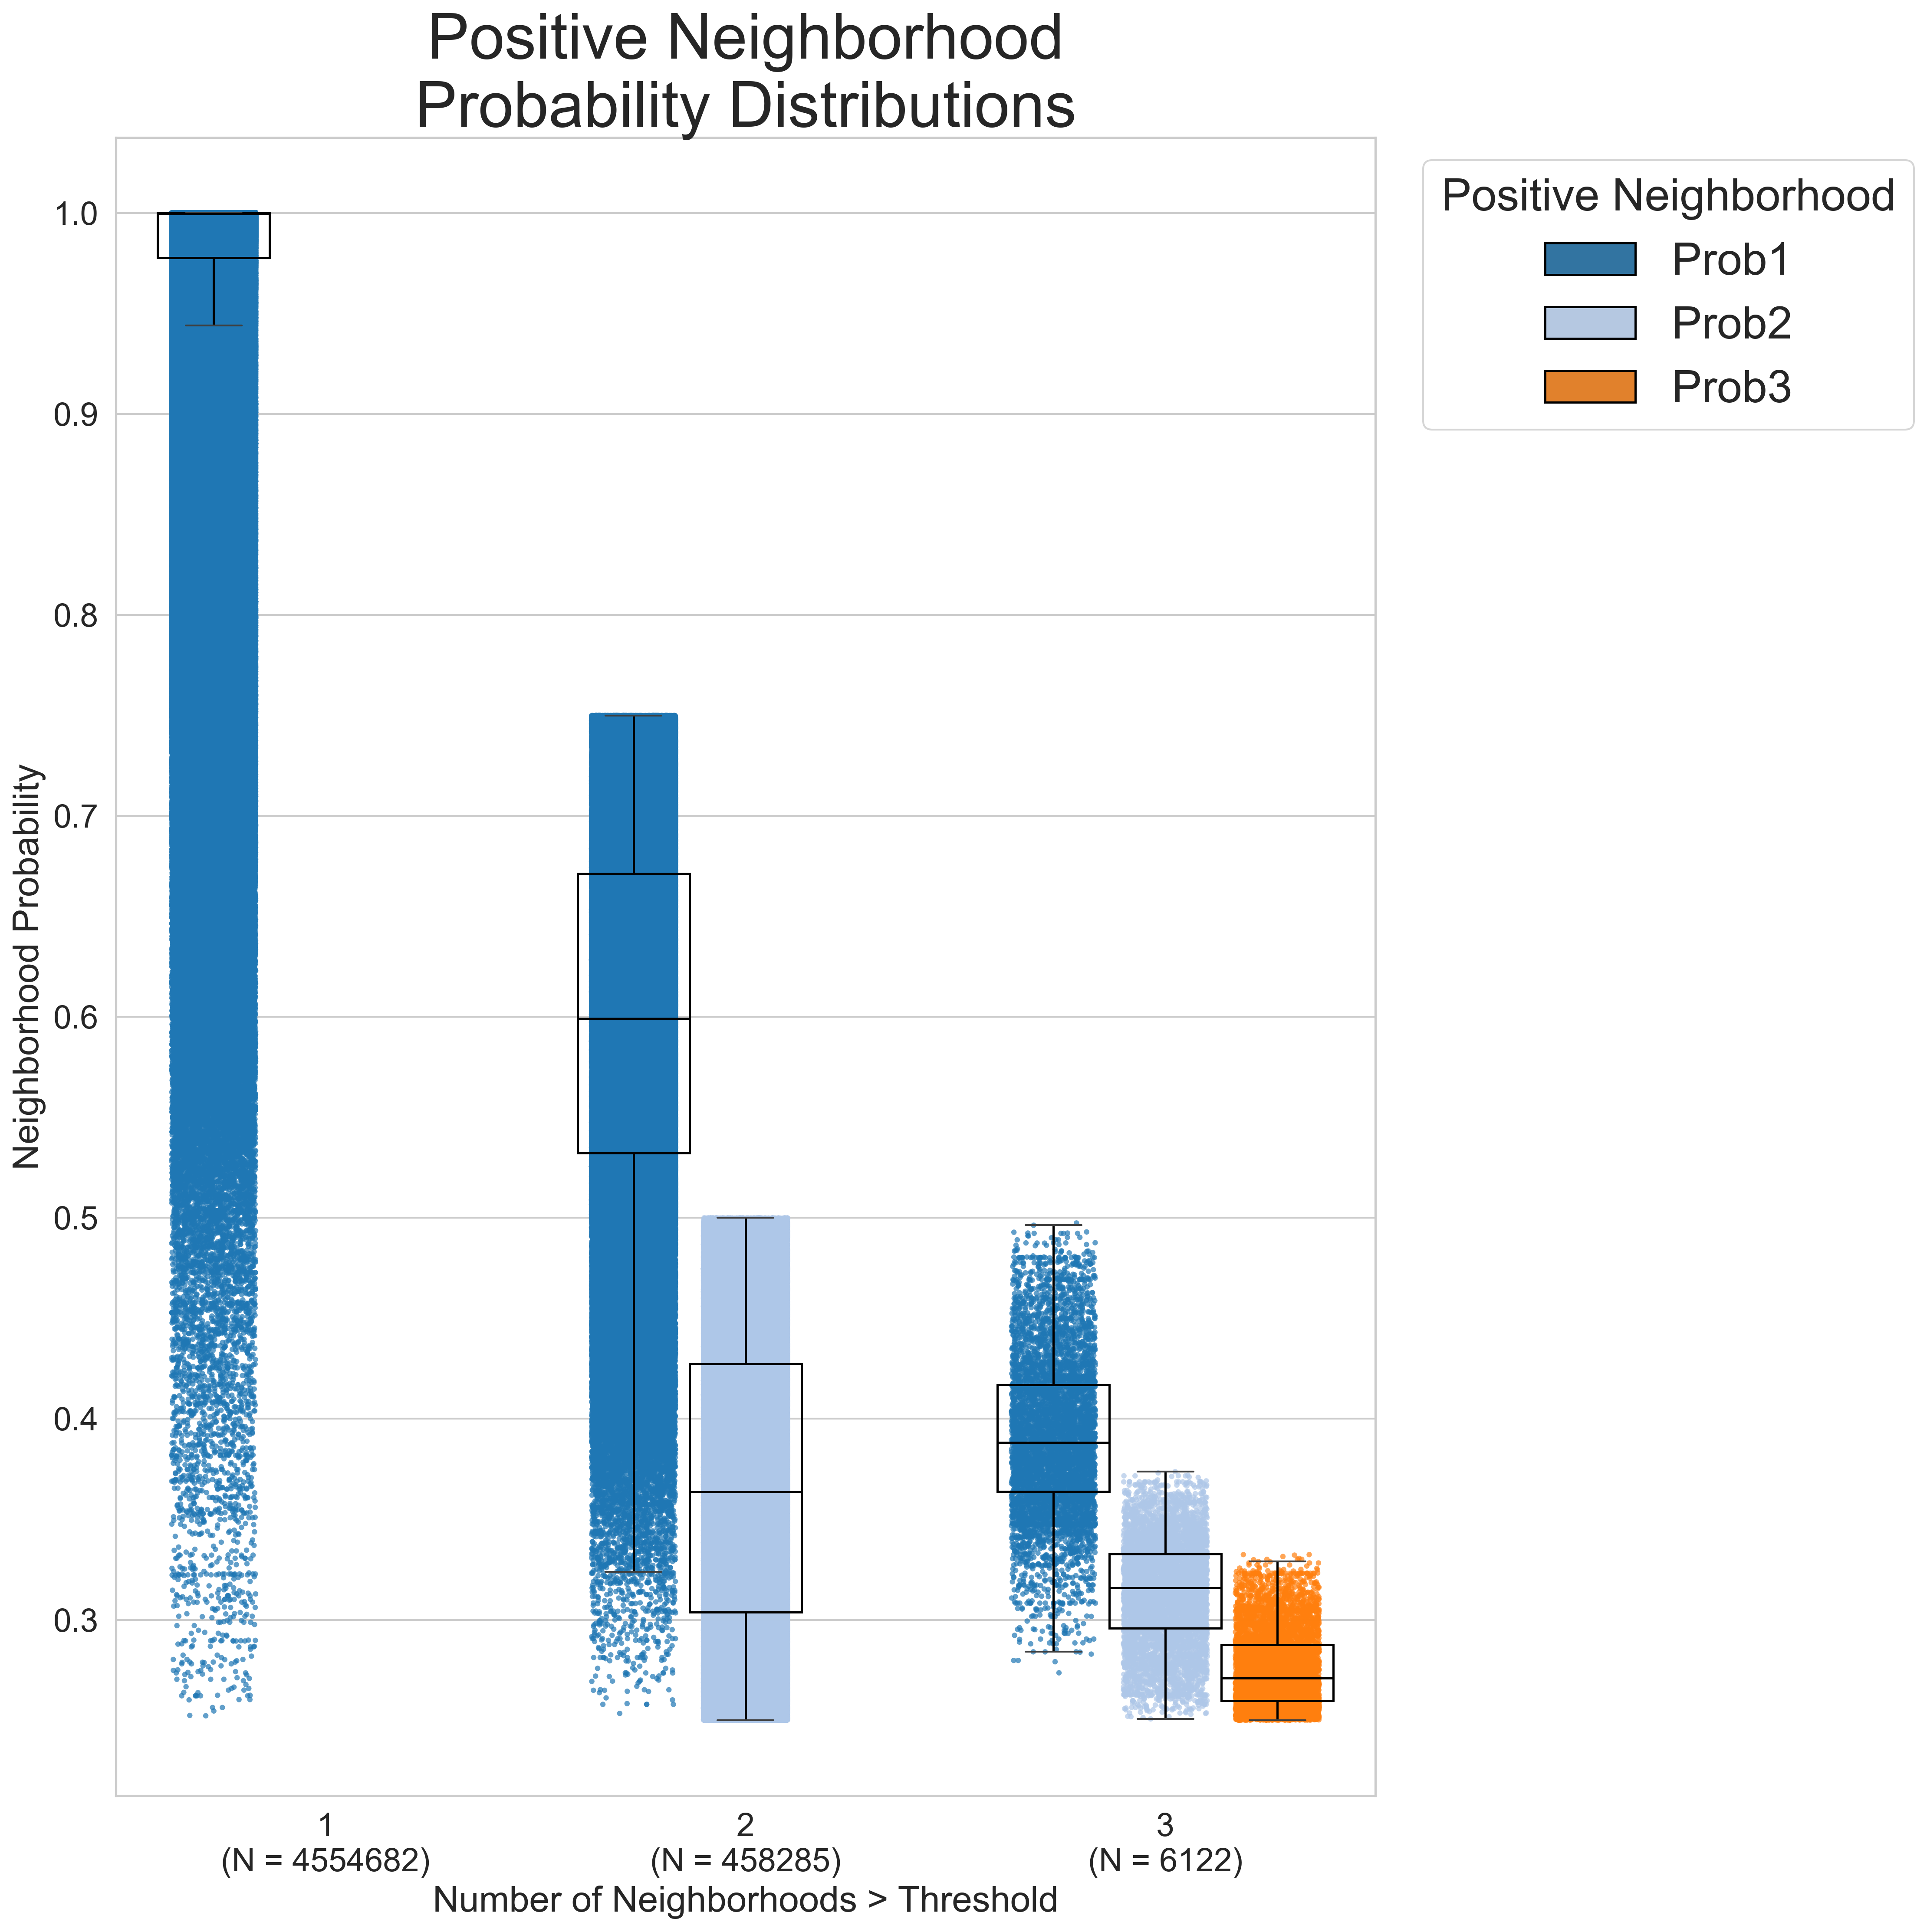

In [9]:
figs = mg.pl.edges_positive_probability(
            cells,
            prob_key="neighborhood_probabilities",
            threshold=0.25,
            save="png",
            show=True
        )

### Step 20. Materialize the probability matrix as a DataFrame
Purpose: Convert the probability matrix stored in `obsm` into an explicit pandas table for the custom analyses that follow.

User-adjustable inputs: No modeling parameters change here. If you rename `prob_key` upstream, make the same change here so the notebook still reads the correct matrix.

Expected output: `probabilities_df` becomes a cell-by-neighborhood probability table aligned to `cells.obs_names`.

In [4]:
probabilities_df = pd.DataFrame(
    cells.obsm["neighborhood_probabilities"],
    index=cells.obs_names,  # restores cell index
    columns=cells.uns["neighborhood_probability_neighborhoods"]
)

### Step 21. Create a stable color mapping for cell types
Purpose: Define and run a helper that assigns each cell type a reproducible qualitative color so all later supplemental plots use a consistent legend.

User-adjustable inputs: If your study has more categories than the combined palettes can support, extend `palette_names` or replace the helper with a custom palette generator.

Expected output: `color_dict`, `color_list`, and `cell_type_list` provide consistent colors for downstream cell-type visualizations.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def make_celltype_palette_strict(df, cell_type_col='Cell_Type'):
    """
    Create a long, non-repeating categorical color palette for each unique cell type.
    Uses a combination of seaborn/matplotlib categorical palettes.
    """
    import seaborn as sns

    # Get unique cell types
    cell_types = sorted(df[cell_type_col].dropna().unique())
    n = len(cell_types)

    # Combine multiple qualitative palettes
    palette_names = ['tab20', 'Set3', 'Set2', 'Paired', 'Dark2', 'Accent']
    combined_colors = []

    for name in palette_names:
        combined_colors.extend(sns.color_palette(name))

    if len(combined_colors) < n:
        raise ValueError(f"Not enough distinct colors for {n} cell types. Max supported is {len(combined_colors)}.")

    # Slice and assign
    final_palette = combined_colors[:n]
    color_dict = dict(zip(cell_types, final_palette))
    return color_dict, final_palette, cell_types

color_dict, color_list, cell_type_list = make_celltype_palette_strict(cells.obs, cell_type_col='Cell_Type')

Shuffle Cell Type Labels

In [22]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# -----------------------------
# Function to compute border proportions
# -----------------------------
def compute_border_proportions(obs):
    """
    Computes the proportion of border cells for each cell type.

    Returns:
        pd.Series indexed by Cell_Type.
    """
    border_mask = obs["Count_Above_Threshold"].isin([2, 3])

    total_counts = obs["Cell_Type"].value_counts()
    border_counts = obs.loc[border_mask, "Cell_Type"].value_counts()

    return (border_counts / total_counts).fillna(0)


# -----------------------------
# Prepare data (only once)
# -----------------------------
obs = cells.obs[["Cell_Type", "Count_Above_Threshold"]].copy()

# Observed proportions
observed = compute_border_proportions(obs)

# -----------------------------
# Permutation test
# -----------------------------
n_perm = 1000

rng = np.random.default_rng(42)

# Reuse the same dataframe each iteration
perm_obs = obs.copy()

null_results = []

for _ in tqdm(range(n_perm), desc="Running permutations"):

    # Shuffle only Cell_Type labels
    perm_obs["Cell_Type"] = rng.permutation(obs["Cell_Type"].values)

    # Compute border proportions
    null_results.append(compute_border_proportions(perm_obs))

# Convert to DataFrame
null_df = pd.DataFrame(null_results).fillna(0)

print(f"\nFinished {n_perm} permutations.")
print(f"Null distribution shape: {null_df.shape}")

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Running permutations: 100%|██████████| 1000/1000 [06:05<00:00,  2.74it/s]


Finished 1000 permutations.
Null distribution shape: (1000, 39)


C:\Users\k1van\AppData\Local\Temp\ipykernel_20072\1541194591.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


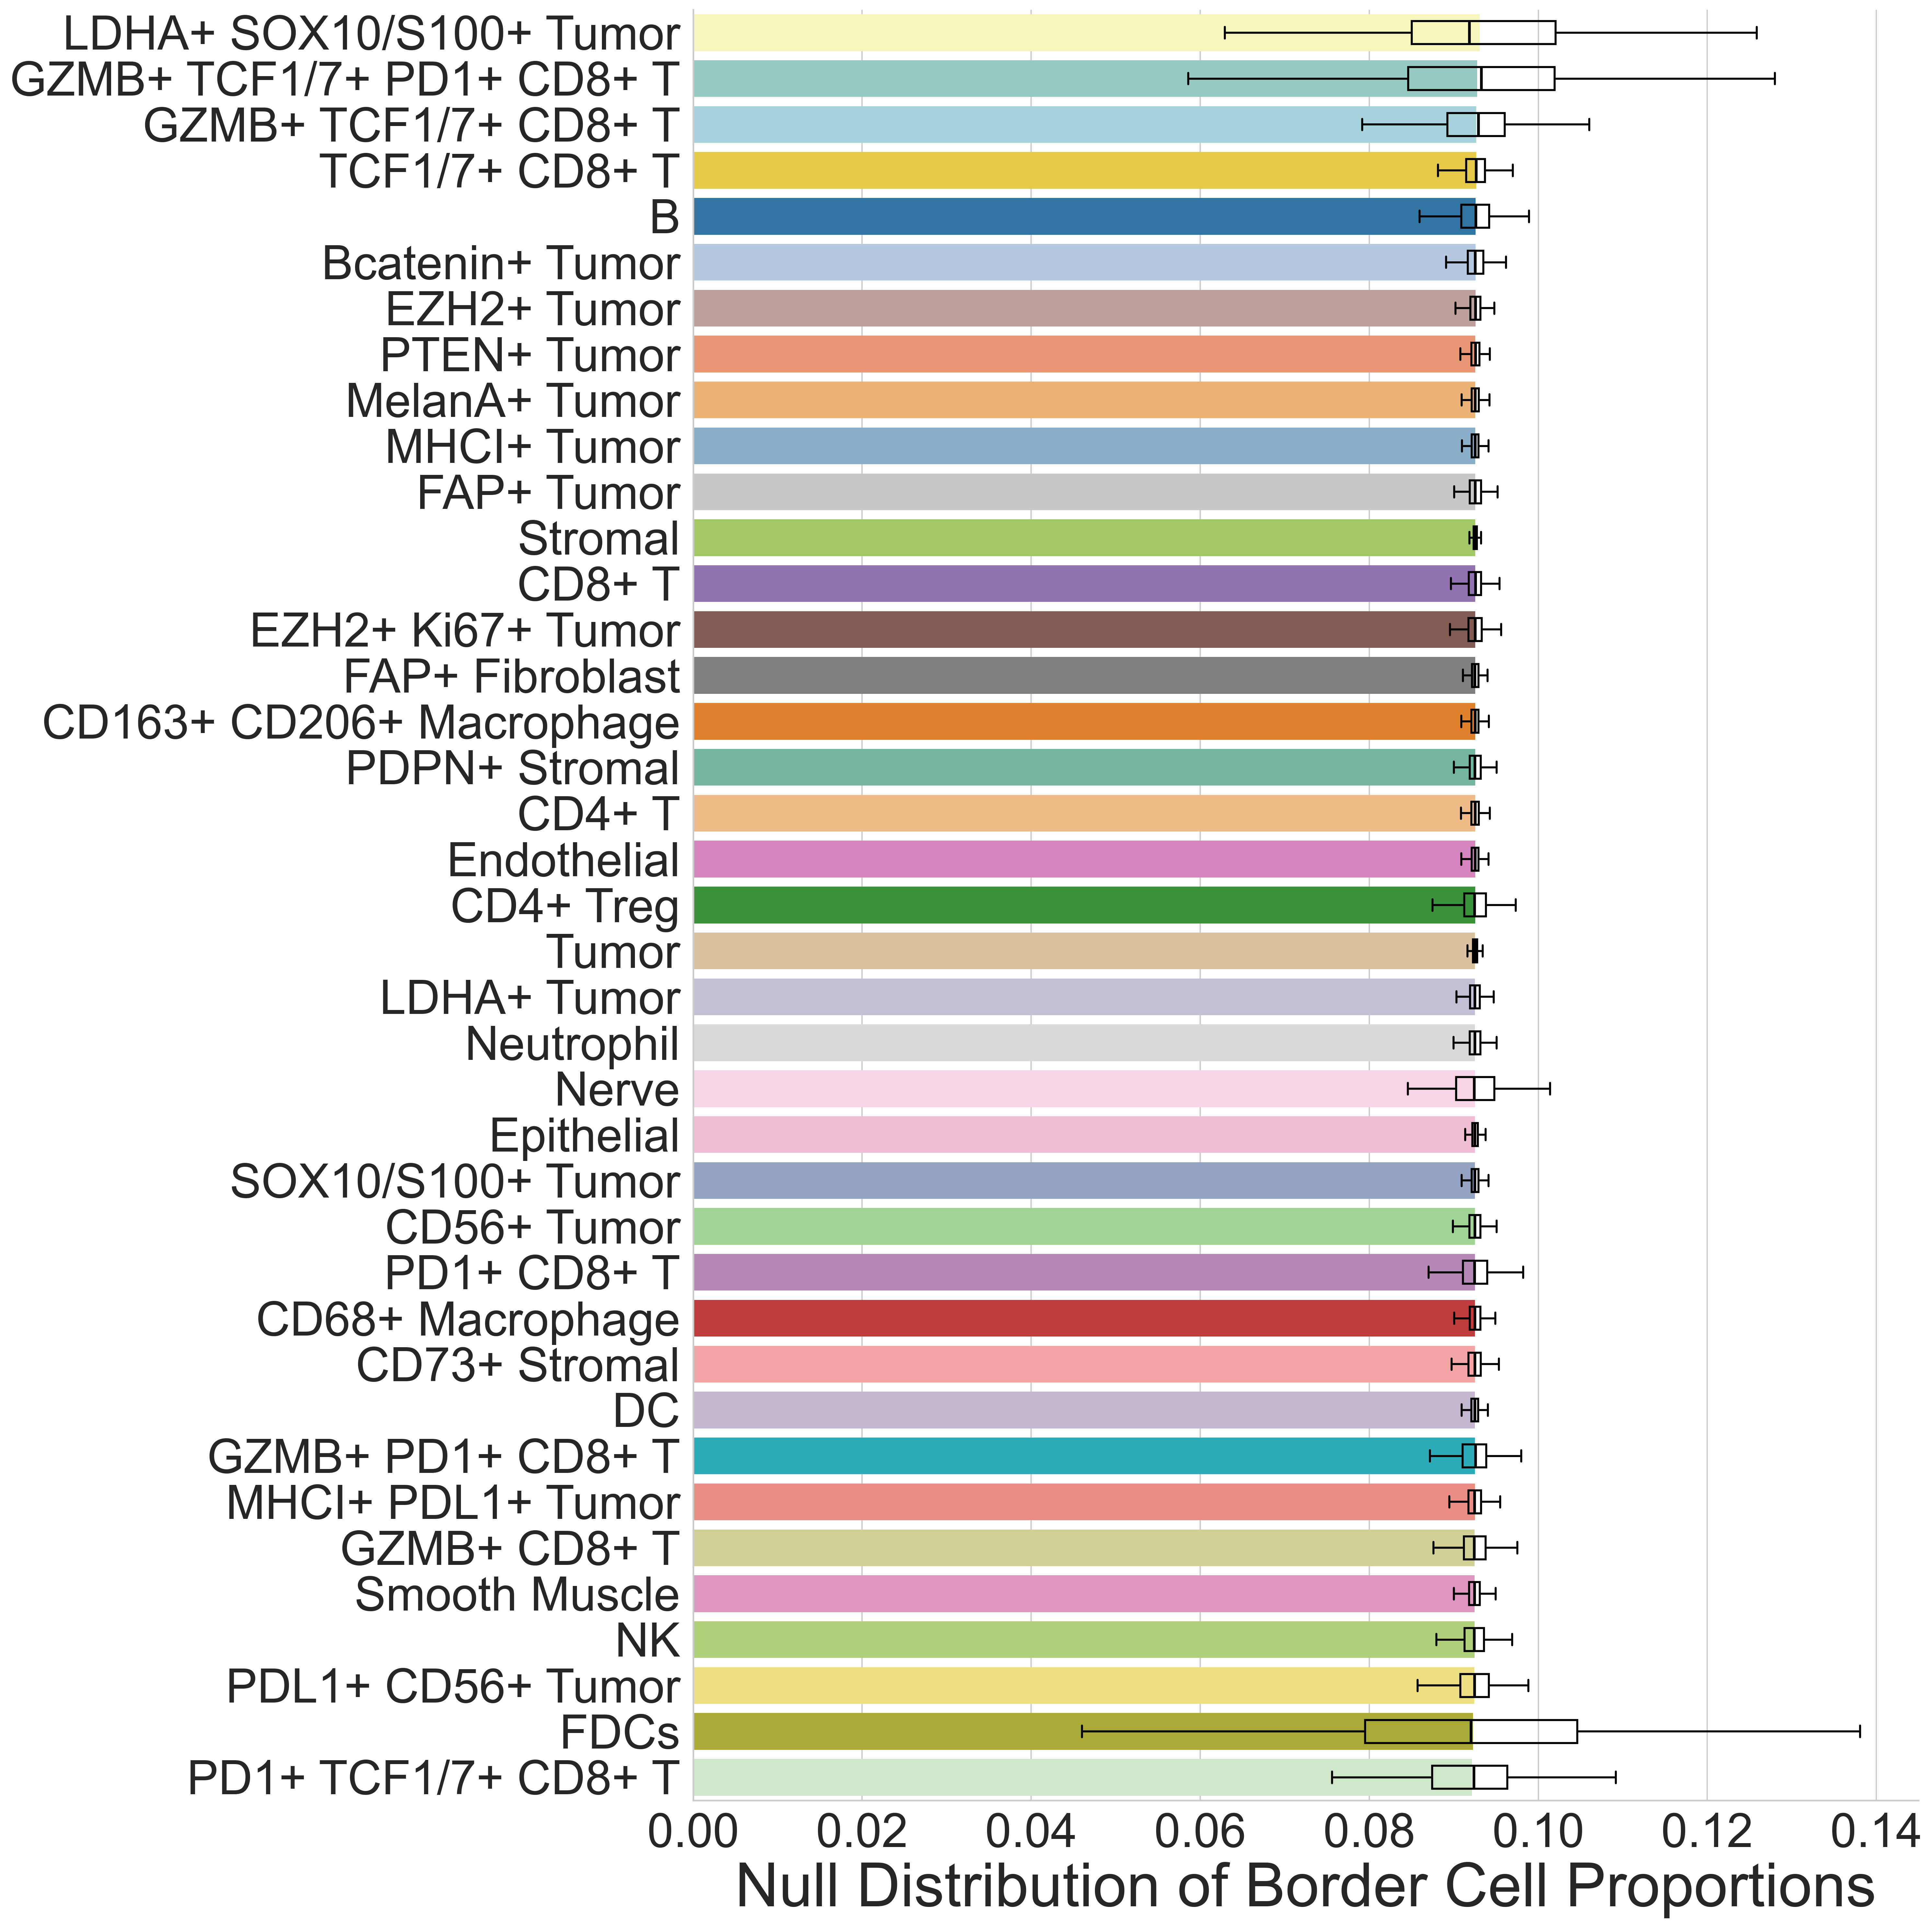

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Mean of null distribution
# -----------------------------
null_mean = null_df.mean()

null_mean_df = (
    null_mean
    .reset_index()
)

null_mean_df.columns = ["Cell_Type", "Proportion"]

# Sort exactly like your other figure
null_mean_df = null_mean_df.sort_values(
    by="Proportion",
    ascending=False
)

order = null_mean_df["Cell_Type"].tolist()

# -----------------------------
# Long-format permutation data
# -----------------------------
null_long = (
    null_df[order]
    .reset_index(drop=True)
    .melt(
        var_name="Cell_Type",
        value_name="Proportion"
    )
)

null_long["Cell_Type"] = pd.Categorical(
    null_long["Cell_Type"],
    categories=order,
    ordered=True
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(20,20), dpi=300)

# Mean null bars
sns.barplot(
    data=null_mean_df,
    y="Cell_Type",
    x="Proportion",
    order=order,
    palette=color_dict,
    edgecolor="none",
    zorder=1
)

# Every permutation
sns.boxplot(
    data=null_long,
    y="Cell_Type",
    x="Proportion",
    order=order,
    color="white",
    width=0.5,
    showcaps=True,
    showfliers=False,   # Set True if you want to show outlier permutations
    boxprops=dict(facecolor="none", edgecolor="black", linewidth=1.5),
    whiskerprops=dict(color="black", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    medianprops=dict(color="black", linewidth=2),
    zorder=10
)

sns.despine(top=True, right=True)

plt.xlabel(
    "Null Distribution of Border Cell Proportions",
    fontsize=45
)

plt.ylabel("")

plt.xticks(fontsize=35)
plt.yticks(fontsize=35)

plt.tight_layout()
plt.show()

### Step 24. Define a helper for pairwise neighborhood-composition comparisons
Purpose: Create a reusable function that splits cells into `n1` only, `n2` only, and shared-positive groups for two neighborhoods, then computes cell-type proportions for each group.

User-adjustable inputs: The key arguments are the input probability table, the two neighborhood names, the cell-type column, and the probability threshold used to define positivity.

Expected output: A helper function that supports the next set of pairwise border-composition plots.

In [27]:
def compute_grouped_proportions(df, n1, n2, cell_type_col='Cell_Type', threshold=0.25):
    pos_1 = df[n1] > threshold
    pos_2 = df[n2] > threshold

    only_1 = df[pos_1 & ~pos_2]
    both = df[pos_1 & pos_2]
    only_2 = df[~pos_1 & pos_2]

    def summarize(sub, label):
        counts = sub[cell_type_col].value_counts(normalize=True)
        df_sub = counts.reset_index()
        df_sub.columns = [cell_type_col, 'Proportion']
        df_sub['Subset'] = label
        return df_sub

    df1 = summarize(only_1, f"{n1}")
    df2 = summarize(both, f"{n1} +\n{n2}")
    df3 = summarize(only_2, f"{n2}")

    all_df = pd.concat([df1, df2, df3], ignore_index=True)

    # Fill in missing combinations
    celltypes = all_df[cell_type_col].unique()
    groups = [f"{n1}", f"{n1} +\n{n2}", f"{n2}"]
    full_index = pd.MultiIndex.from_product([celltypes, groups], names=[cell_type_col, 'Subset'])
    return all_df.set_index([cell_type_col, 'Subset']).reindex(full_index, fill_value=0).reset_index()

### Step 25. Attach cell-type labels to the probability table
Purpose: Bring the `Cell_Type` annotation into `probabilities_df` so the custom pairwise summaries can be computed directly from one DataFrame.

User-adjustable inputs: If your cell-type annotation lives under a different column name, change it here and in the helper above.

Expected output: `probabilities_df` now contains both probability columns and the categorical cell-type label needed for stratified summaries.

In [30]:
from tqdm.auto import tqdm
import numpy as np

# Keep a clean copy
base_probabilities = probabilities_df.copy()

# Add the original cell types once
base_probabilities["Cell_Type"] = cells.obs["Cell_Type"].values

rng = np.random.default_rng(42)

n_perm = 1000

null_pivots = []

In [ ]:
#probabilities_df = pd.concat([probabilities_df, cells.obs['Cell_Type']], axis=1)

### Step 26. Compare two melanoma neighborhoods as a stacked composition plot
Purpose: Use the helper function to contrast cell-type composition in `Inflamed Tumor`, `Productive T cell & Tumor`, and their overlap, then add an average reference profile.

User-adjustable inputs: Change `n1`, `n2`, the positivity threshold inside `compute_grouped_proportions`, or the plotting order if you want to compare a different pair of neighborhoods.

Expected output: A stacked horizontal bar chart and separate legend summarizing how the two neighborhoods and their shared-positive cells differ in cell-type composition.

Grouped permutations: 100%|██████████| 1000/1000 [08:00<00:00,  2.08it/s]
C:\Users\k1van\AppData\Local\Temp\ipykernel_20072\611221226.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(pivot.index, fontsize=30)


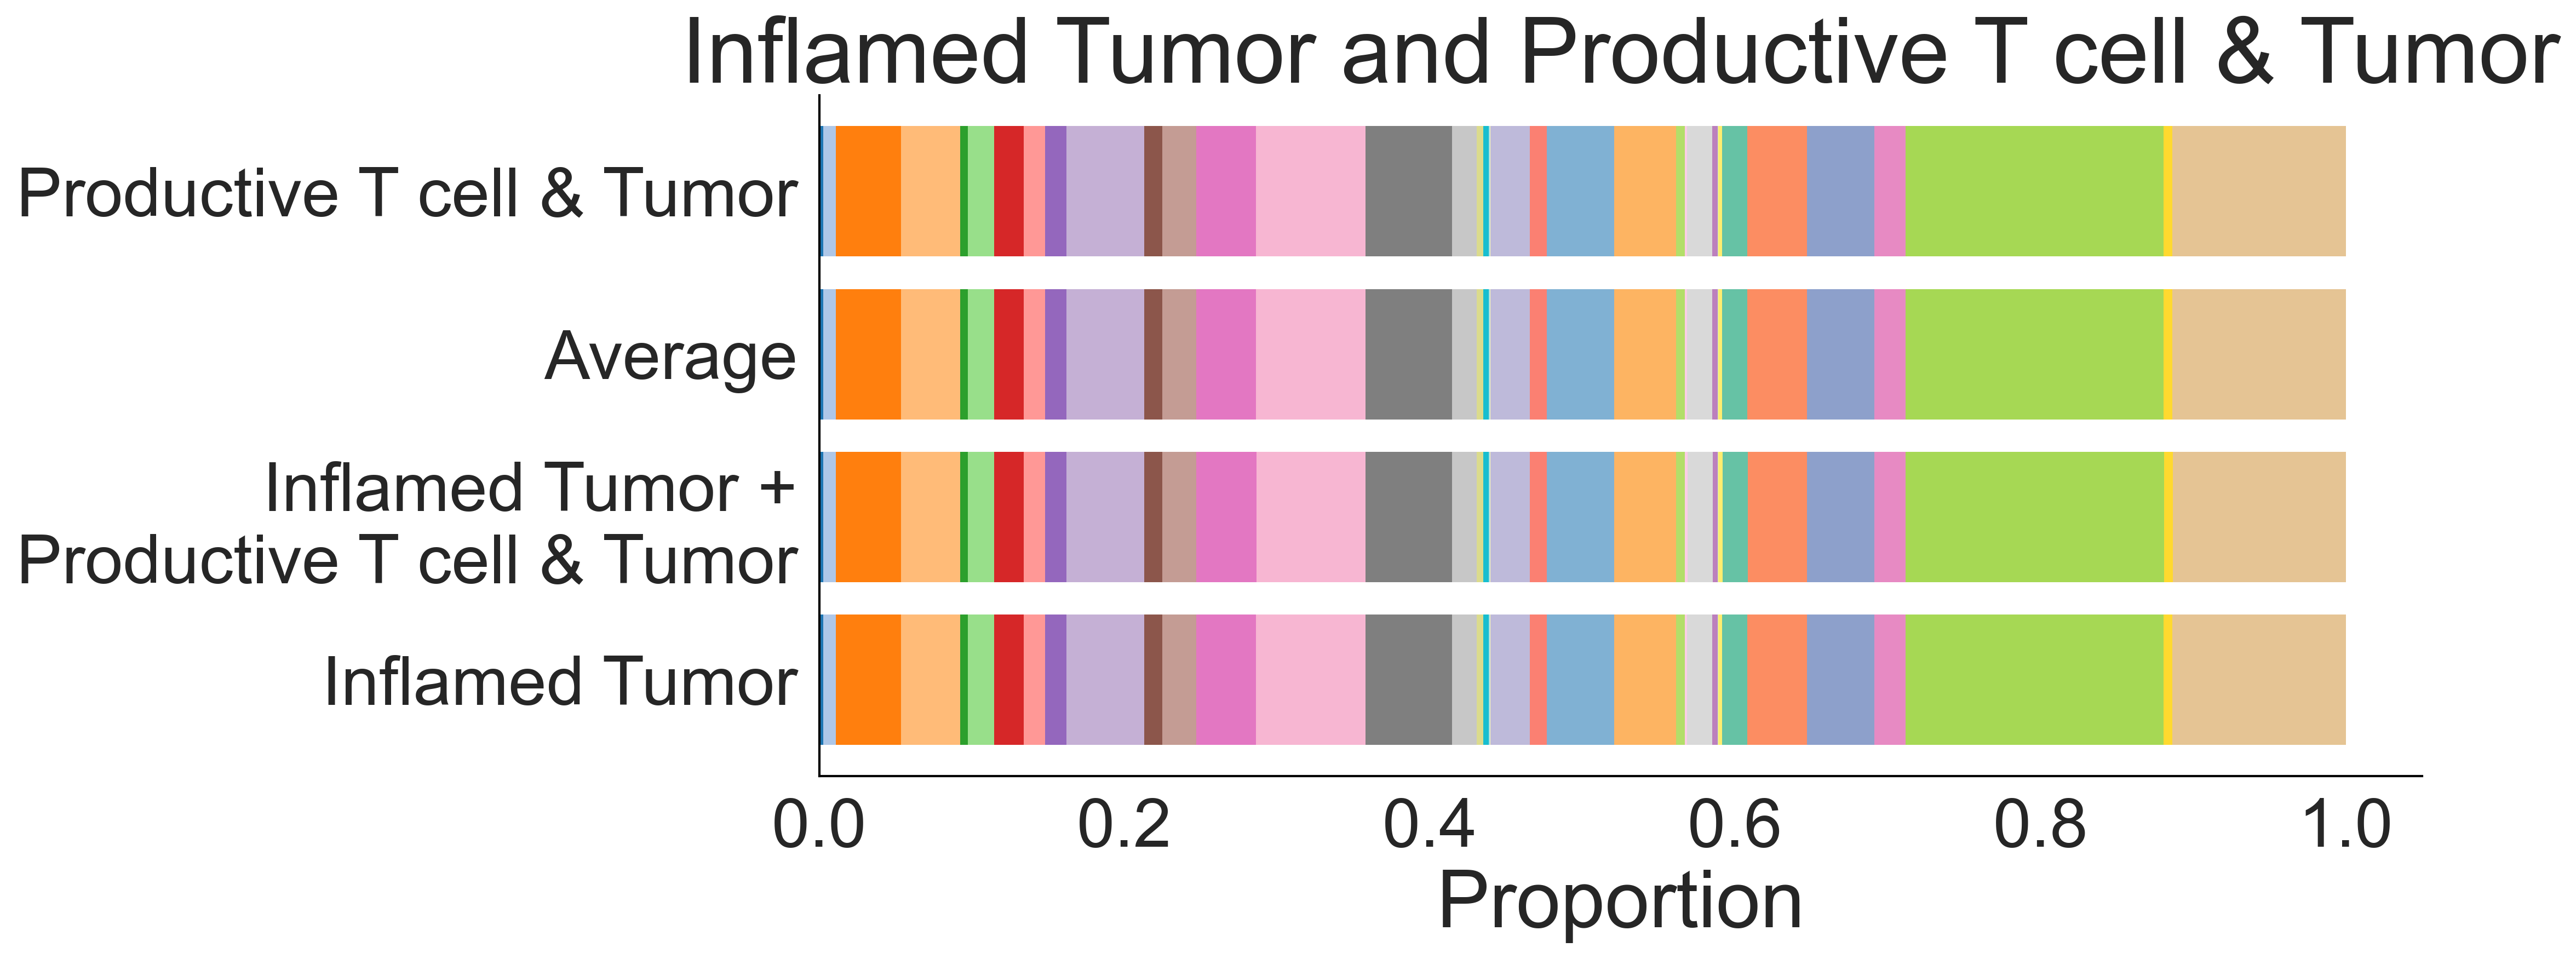

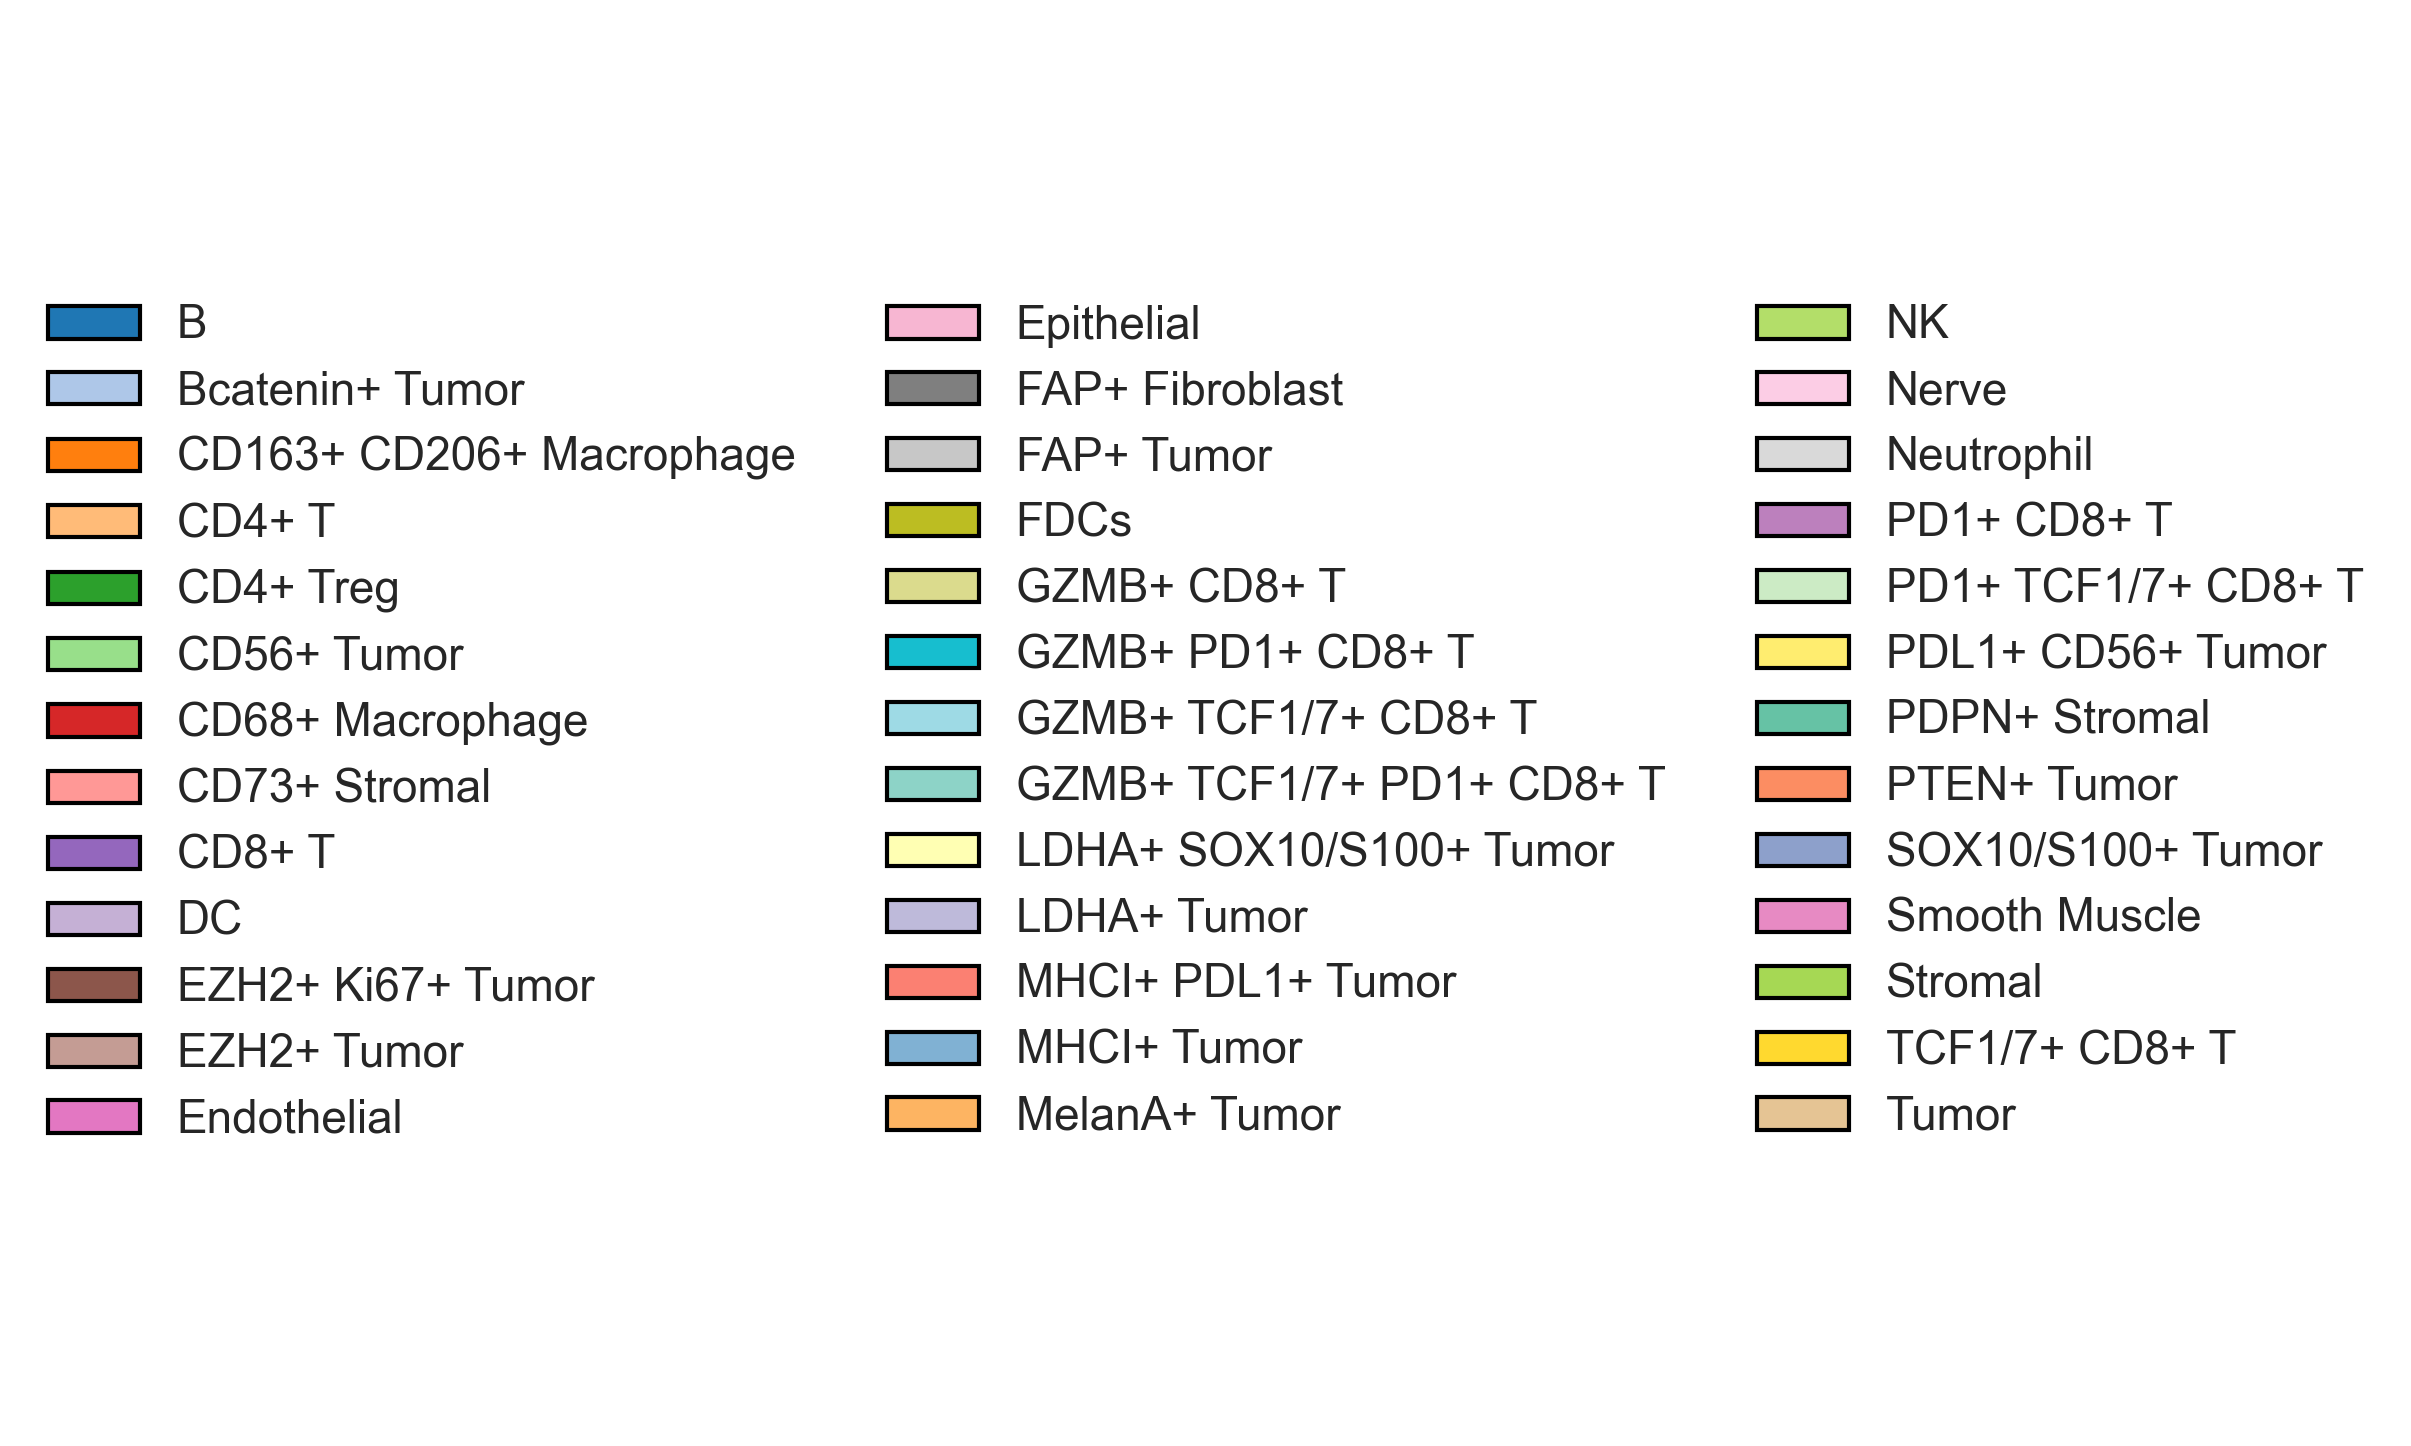

In [31]:
n1, n2 = "Inflamed Tumor", "Productive T cell & Tumor"

subset_order = [f"{n1}", f"{n1} +\n{n2}", "Average", f"{n2}"]

for i in tqdm(range(n_perm), desc="Grouped permutations"):

    perm_df = base_probabilities.copy()

    perm_df["Cell_Type"] = rng.permutation(
        base_probabilities["Cell_Type"].values
    )

    df_plot = compute_grouped_proportions(
        perm_df,
        n1,
        n2,
        cell_type_col="Cell_Type",
        threshold=0.25
    )

    pivot = (
        df_plot
        .pivot(index="Subset",
               columns="Cell_Type",
               values="Proportion")
        .fillna(0)
    )

    avg = (pivot.loc[n1] + pivot.loc[n2]) / 2
    pivot.loc["Average"] = avg

    pivot = pivot.reindex(subset_order)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)

    null_pivots.append(pivot)

# Mean null composition
pivot = sum(null_pivots) / len(null_pivots)
# --- Main stacked bar plot (HORIZONTAL) ---
fig, ax = plt.subplots(figsize=(15, 6), dpi=300)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bottom = np.zeros(len(pivot))

for col in pivot.columns:  # each col = a cell type
    bar_color = color_dict.get(col, "#cccccc")
    # NOTE: switched from bar() to barh()
    ax.barh(
        pivot.index, 
        pivot[col], 
        left=bottom, 
        label=col, 
        color=bar_color,
        edgecolor="none",   # ← ADD THIS
        linewidth=0         # ← AND THIS
    )
    bottom += pivot[col].values

# Turn OFF grid
ax.grid(False)

# Spines
for spine in ["left", "bottom"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(1)
    ax.spines[spine].set_color("black")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Labels and formatting
ax.set_title(f"{n1} and {n2}", fontsize=40)
ax.set_xlabel("Proportion", fontsize=35)  # now x-axis shows proportions
ax.set_ylabel("")  # y-axis categories (the subsets)

ax.set_yticklabels(pivot.index, fontsize=30)
ax.tick_params(axis="x", labelsize=30)

plt.tight_layout()
plt.show()

# --- Separate legend figure ---
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color_dict.get(ct, "#cccccc"), edgecolor="black", label=ct)
    for ct in pivot.columns
]

fig_leg = plt.figure(figsize=(3, 6), dpi=300)
plt.legend(handles=legend_elements, loc="center", ncol=3, frameon=False)
plt.axis("off")
plt.show()


### Step 27. Inspect the modeled cell metadata before supplemental plotting
Purpose: Preview `cells.obs` again so the supplemental panel calculations can be cross-checked against the main modeled dataset.

User-adjustable inputs: This is a diagnostic checkpoint with no user-facing parameters.

Expected output: A table view of the modeled observation metadata.

In [29]:
cells.obs

,Unnamed: 0,CCR7,CD103,CD11b,CD11c,CD138,CD15,CD163,CD20,CD206,...,Cell_Type_Sub,CD38,filename,region,x,y,Cell_Type,Overall_Cell_Type,Neighborhood,Count_Above_Threshold
0,0,-0.362926,-0.729925,-0.150820,-0.363121,-0.193573,-0.376392,-0.277710,-0.096556,-0.326673,...,CD73+ Stromal,NaN,21_06_23_reg001.tsv,2,3981,47146,CD73+ Stromal,Stromal,Stromal Enriched,1
1,1,-0.542319,-0.723530,-0.193650,-0.359325,-0.199382,-0.394698,-0.219857,-0.126534,-0.333797,...,CD73+ Stromal,NaN,21_06_23_reg001.tsv,2,5286,39373,CD73+ Stromal,Stromal,Stromal Enriched,1
2,2,-0.444684,-0.497128,-0.329550,-0.292091,-0.201171,-0.202878,-0.309667,-0.135984,-0.347450,...,Endothelial,NaN,21_06_23_reg001.tsv,2,22899,42306,Endothelial,Stromal,Vasculature,1
3,3,-0.829088,-1.629941,-0.341772,-0.380618,-0.255592,-0.419650,-0.115570,-0.118611,0.245775,...,CD73+ Stromal,NaN,21_06_23_reg001.tsv,2,5747,45479,CD73+ Stromal,Stromal,Stromal Enriched,1
4,4,0.111211,-0.134976,3.659562,0.540194,-0.181382,5.446553,-0.212632,-0.125781,-0.246451,...,Neutrophil,NaN,21_06_23_reg001.tsv,2,17460,49393,Neutrophil,Immune,Neutrophil Enriched,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,5019154,0.098215,-0.083622,-0.217149,-0.437058,-0.297181,-0.058682,-0.292474,-0.041080,-0.335148,...,Stromal,-0.723163,23_07_06_reg002.tsv,2,4283,6987,Stromal,Stromal,Proliferating Tumor,1
5019155,5019155,-0.240248,-0.113821,-0.464631,-0.433815,-0.275257,-0.066953,-0.282331,-0.028372,-0.194535,...,Tumor,-0.350178,23_07_06_reg002.tsv,2,17172,6095,MelanA+ Tumor,Tumor,Stromal Enriched,1
5019156,5019156,-0.423292,-0.166772,-0.623979,-0.435652,-0.300200,-0.055559,-0.314097,-0.139452,-0.301023,...,Stromal,-0.099238,23_07_06_reg002.tsv,2,16878,4870,Stromal,Stromal,Stromal Enriched,1
5019157,5019157,1.402914,0.407268,1.345068,-0.353550,-0.301476,-0.048187,1.235023,-0.134024,0.436833,...,Tumor,-0.057958,23_07_06_reg002.tsv,2,13326,10841,Tumor,Tumor,Macrophage Enriched Immune,1


### Step 28. Inspect the probability table before supplemental plotting
Purpose: Preview the long-format probability table to verify that the custom supplemental calculations are drawing from the expected columns.

User-adjustable inputs: No parameters change here; use the preview to confirm neighborhood names and metadata joins.

Expected output: A table view of the per-cell probability matrix.

In [30]:
probabilities_df

,Stromal Enriched,Vasculature,Neutrophil Enriched,Macrophage Enriched Immune,Vasculature & Immune,Productive T cell & Tumor,Proliferating Tumor,Inflamed Tumor,Tumor & Immune,Epithelial/Skin Appendages,Resting Tumor,PDPN+ Stromal Enriched,Follicle,Perivascular,Immune Infiltrate,DC Enriched Immune,Cell_Type
0,1.000000e+00,9.822844e-177,1.718159e-96,7.985203e-35,1.287316e-42,1.115300e-240,0.000000e+00,0.000000e+00,2.091633e-96,3.211450e-79,7.573185e-273,9.689886e-84,1.194616e-127,4.087384e-81,6.457861e-91,1.794378e-185,CD73+ Stromal
1,1.000000e+00,2.395280e-58,8.294493e-35,4.733666e-16,1.644260e-19,4.621986e-71,5.511457e-145,3.826287e-150,5.047315e-41,6.442329e-29,1.827326e-95,3.707959e-30,4.109105e-50,1.052297e-25,9.023131e-42,1.306629e-67,CD73+ Stromal
2,1.663227e-84,9.999888e-01,5.233530e-30,6.599728e-21,3.157365e-41,9.138792e-06,2.507844e-15,1.311557e-06,6.475173e-12,2.231822e-160,1.484603e-21,5.063616e-37,7.384508e-07,2.771081e-86,5.630692e-21,3.523427e-26,Endothelial
3,1.000000e+00,1.527983e-220,4.068092e-119,1.597646e-43,5.540362e-53,3.299943e-303,0.000000e+00,0.000000e+00,3.819557e-120,8.480105e-92,0.000000e+00,5.980730e-105,2.060861e-158,2.952022e-101,5.180010e-113,1.349377e-232,CD73+ Stromal
4,7.632430e-189,8.361201e-194,1.000000e+00,3.942001e-89,4.039850e-100,5.987526e-173,0.000000e+00,1.030714e-264,1.185926e-68,0.000000e+00,8.603425e-115,5.855969e-211,3.517905e-82,0.000000e+00,2.107462e-145,7.528004e-138,Neutrophil
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,9.996948e-01,1.879720e-13,1.452876e-33,2.332866e-23,4.499363e-20,7.280023e-20,4.802369e-60,4.380563e-63,3.050675e-04,1.025893e-07,5.743900e-26,1.343226e-77,2.417502e-15,2.128595e-65,4.661821e-62,9.477136e-57,Stromal
5019155,1.000000e+00,5.590701e-19,5.188413e-19,1.164053e-11,1.621109e-11,5.247034e-22,1.785026e-36,7.672648e-40,2.402479e-18,6.727805e-12,2.156728e-38,2.570974e-27,2.950963e-22,2.238530e-18,7.460772e-31,4.898942e-33,MelanA+ Tumor
5019156,1.000000e+00,3.409260e-24,1.983612e-22,1.293168e-10,2.496181e-14,2.545438e-22,2.183286e-14,9.212232e-20,7.829675e-29,1.379860e-22,1.158323e-56,1.403319e-15,1.326685e-30,6.097233e-12,1.181868e-32,1.266952e-38,Stromal
5019157,9.999587e-01,2.683558e-12,2.906108e-08,3.776751e-06,2.190951e-06,1.785300e-11,2.009144e-14,3.792442e-16,3.035166e-14,4.052924e-12,8.557954e-24,1.674929e-07,6.816478e-16,3.515218e-05,2.544908e-13,4.077540e-16,Tumor


### Step 33. Attach coordinates and region IDs to `probabilities_df`
Purpose: Copy over the spatial metadata needed for region-level filtering and custom heatmaps that operate directly on the probability DataFrame.

User-adjustable inputs: If your coordinate or region columns use different names, update the assignments here to match your schema.

Expected output: `probabilities_df` now contains neighborhood probabilities plus the minimal spatial metadata needed for custom plots.

In [32]:
base_probabilities["filename"] = cells.obs["filename"].values
base_probabilities["Count_Above_Threshold"] = cells.obs["Count_Above_Threshold"].values
base_probabilities["x"] = cells.obs["x"].values
base_probabilities["y"] = cells.obs["y"].values

In [ ]:
# probabilities_df['filename'] = cells.obs['filename']
# probabilities_df['Count_Above_Threshold'] = cells.obs['Count_Above_Threshold']
# probabilities_df['x'] = cells.obs['x']
# probabilities_df['y'] = cells.obs['y']
# probabilities_df

,Stromal Enriched,Vasculature,Neutrophil Enriched,Macrophage Enriched Immune,Vasculature & Immune,Productive T cell & Tumor,Proliferating Tumor,Inflamed Tumor,Tumor & Immune,Epithelial/Skin Appendages,...,PDPN+ Stromal Enriched,Follicle,Perivascular,Immune Infiltrate,DC Enriched Immune,Cell_Type,filename,Count_Above_Threshold,x,y
0,1.000000e+00,9.822844e-177,1.718159e-96,7.985203e-35,1.287316e-42,1.115300e-240,0.000000e+00,0.000000e+00,2.091633e-96,3.211450e-79,...,9.689886e-84,1.194616e-127,4.087384e-81,6.457861e-91,1.794378e-185,CD73+ Stromal,21_06_23_reg001.tsv,1,3981,47146
1,1.000000e+00,2.395280e-58,8.294493e-35,4.733666e-16,1.644260e-19,4.621986e-71,5.511457e-145,3.826287e-150,5.047315e-41,6.442329e-29,...,3.707959e-30,4.109105e-50,1.052297e-25,9.023131e-42,1.306629e-67,CD73+ Stromal,21_06_23_reg001.tsv,1,5286,39373
2,1.663227e-84,9.999888e-01,5.233530e-30,6.599728e-21,3.157365e-41,9.138792e-06,2.507844e-15,1.311557e-06,6.475173e-12,2.231822e-160,...,5.063616e-37,7.384508e-07,2.771081e-86,5.630692e-21,3.523427e-26,Endothelial,21_06_23_reg001.tsv,1,22899,42306
3,1.000000e+00,1.527983e-220,4.068092e-119,1.597646e-43,5.540362e-53,3.299943e-303,0.000000e+00,0.000000e+00,3.819557e-120,8.480105e-92,...,5.980730e-105,2.060861e-158,2.952022e-101,5.180010e-113,1.349377e-232,CD73+ Stromal,21_06_23_reg001.tsv,1,5747,45479
4,7.632430e-189,8.361201e-194,1.000000e+00,3.942001e-89,4.039850e-100,5.987526e-173,0.000000e+00,1.030714e-264,1.185926e-68,0.000000e+00,...,5.855969e-211,3.517905e-82,0.000000e+00,2.107462e-145,7.528004e-138,Neutrophil,21_06_23_reg001.tsv,1,17460,49393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,9.996948e-01,1.879720e-13,1.452876e-33,2.332866e-23,4.499363e-20,7.280023e-20,4.802369e-60,4.380563e-63,3.050675e-04,1.025893e-07,...,1.343226e-77,2.417502e-15,2.128595e-65,4.661821e-62,9.477136e-57,Stromal,23_07_06_reg002.tsv,1,4283,6987
5019155,1.000000e+00,5.590701e-19,5.188413e-19,1.164053e-11,1.621109e-11,5.247034e-22,1.785026e-36,7.672648e-40,2.402479e-18,6.727805e-12,...,2.570974e-27,2.950963e-22,2.238530e-18,7.460772e-31,4.898942e-33,MelanA+ Tumor,23_07_06_reg002.tsv,1,17172,6095
5019156,1.000000e+00,3.409260e-24,1.983612e-22,1.293168e-10,2.496181e-14,2.545438e-22,2.183286e-14,9.212232e-20,7.829675e-29,1.379860e-22,...,1.403319e-15,1.326685e-30,6.097233e-12,1.181868e-32,1.266952e-38,Stromal,23_07_06_reg002.tsv,1,16878,4870
5019157,9.999587e-01,2.683558e-12,2.906108e-08,3.776751e-06,2.190951e-06,1.785300e-11,2.009144e-14,3.792442e-16,3.035166e-14,4.052924e-12,...,1.674929e-07,6.816478e-16,3.515218e-05,2.544908e-13,4.077540e-16,Tumor,23_07_06_reg002.tsv,1,13326,10841


### Step 37. Reinspect the probability table before the heatmap panel
Purpose: Display `probabilities_df` to confirm that the matrix still contains the expected neighborhood columns before the custom enrichment heatmap is built.

User-adjustable inputs: No parameters change here.

Expected output: A quick QC preview of the probability table.

In [39]:
probabilities_df

,Stromal Enriched,Vasculature,Neutrophil Enriched,Macrophage Enriched Immune,Vasculature & Immune,Productive T cell & Tumor,Proliferating Tumor,Inflamed Tumor,Tumor & Immune,Epithelial/Skin Appendages,...,PDPN+ Stromal Enriched,Follicle,Perivascular,Immune Infiltrate,DC Enriched Immune,Cell_Type,filename,Count_Above_Threshold,x,y
0,1.000000e+00,9.822844e-177,1.718159e-96,7.985203e-35,1.287316e-42,1.115300e-240,0.000000e+00,0.000000e+00,2.091633e-96,3.211450e-79,...,9.689886e-84,1.194616e-127,4.087384e-81,6.457861e-91,1.794378e-185,CD73+ Stromal,21_06_23_reg001.tsv,1,3981,47146
1,1.000000e+00,2.395280e-58,8.294493e-35,4.733666e-16,1.644260e-19,4.621986e-71,5.511457e-145,3.826287e-150,5.047315e-41,6.442329e-29,...,3.707959e-30,4.109105e-50,1.052297e-25,9.023131e-42,1.306629e-67,CD73+ Stromal,21_06_23_reg001.tsv,1,5286,39373
2,1.663227e-84,9.999888e-01,5.233530e-30,6.599728e-21,3.157365e-41,9.138792e-06,2.507844e-15,1.311557e-06,6.475173e-12,2.231822e-160,...,5.063616e-37,7.384508e-07,2.771081e-86,5.630692e-21,3.523427e-26,Endothelial,21_06_23_reg001.tsv,1,22899,42306
3,1.000000e+00,1.527983e-220,4.068092e-119,1.597646e-43,5.540362e-53,3.299943e-303,0.000000e+00,0.000000e+00,3.819557e-120,8.480105e-92,...,5.980730e-105,2.060861e-158,2.952022e-101,5.180010e-113,1.349377e-232,CD73+ Stromal,21_06_23_reg001.tsv,1,5747,45479
4,7.632430e-189,8.361201e-194,1.000000e+00,3.942001e-89,4.039850e-100,5.987526e-173,0.000000e+00,1.030714e-264,1.185926e-68,0.000000e+00,...,5.855969e-211,3.517905e-82,0.000000e+00,2.107462e-145,7.528004e-138,Neutrophil,21_06_23_reg001.tsv,1,17460,49393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,9.996948e-01,1.879720e-13,1.452876e-33,2.332866e-23,4.499363e-20,7.280023e-20,4.802369e-60,4.380563e-63,3.050675e-04,1.025893e-07,...,1.343226e-77,2.417502e-15,2.128595e-65,4.661821e-62,9.477136e-57,Stromal,23_07_06_reg002.tsv,1,4283,6987
5019155,1.000000e+00,5.590701e-19,5.188413e-19,1.164053e-11,1.621109e-11,5.247034e-22,1.785026e-36,7.672648e-40,2.402479e-18,6.727805e-12,...,2.570974e-27,2.950963e-22,2.238530e-18,7.460772e-31,4.898942e-33,MelanA+ Tumor,23_07_06_reg002.tsv,1,17172,6095
5019156,1.000000e+00,3.409260e-24,1.983612e-22,1.293168e-10,2.496181e-14,2.545438e-22,2.183286e-14,9.212232e-20,7.829675e-29,1.379860e-22,...,1.403319e-15,1.326685e-30,6.097233e-12,1.181868e-32,1.266952e-38,Stromal,23_07_06_reg002.tsv,1,16878,4870
5019157,9.999587e-01,2.683558e-12,2.906108e-08,3.776751e-06,2.190951e-06,1.785300e-11,2.009144e-14,3.792442e-16,3.035166e-14,4.052924e-12,...,1.674929e-07,6.816478e-16,3.515218e-05,2.544908e-13,4.077540e-16,Tumor,23_07_06_reg002.tsv,1,13326,10841


### Step 40. Reinspect the probability table before neighborhood-level bar-and-dot summaries
Purpose: Preview the working probability table before computing neighborhood-specific border enrichment with region-level replicates.

User-adjustable inputs: No parameters change here.

Expected output: A QC preview of the current probability table.

In [42]:
probabilities_df

,Stromal Enriched,Vasculature,Neutrophil Enriched,Macrophage Enriched Immune,Vasculature & Immune,Productive T cell & Tumor,Proliferating Tumor,Inflamed Tumor,Tumor & Immune,Epithelial/Skin Appendages,...,Follicle,Perivascular,Immune Infiltrate,DC Enriched Immune,Cell_Type,filename,Count_Above_Threshold,x,y,is_border
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,CD73+ Stromal,21_06_23_reg001.tsv,1,3981,47146,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,CD73+ Stromal,21_06_23_reg001.tsv,1,5286,39373,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,Endothelial,21_06_23_reg001.tsv,1,22899,42306,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,CD73+ Stromal,21_06_23_reg001.tsv,1,5747,45479,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,Neutrophil,21_06_23_reg001.tsv,1,17460,49393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,Stromal,23_07_06_reg002.tsv,1,4283,6987,0
5019155,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,MelanA+ Tumor,23_07_06_reg002.tsv,1,17172,6095,0
5019156,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,Stromal,23_07_06_reg002.tsv,1,16878,4870,0
5019157,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,Tumor,23_07_06_reg002.tsv,1,13326,10841,0


### Step 42. Choose the neighborhood pair for border-enrichment modeling
Purpose: Define the two neighborhoods that will be compared in the dedicated border-enrichment plot and optionally provide a restricted set of neighborhoods for the auxiliary per-row neighborhood-count calculation.

User-adjustable inputs: Change `N1`, `N2`, and `neighborhoods_example` to study a different biological interface.

Expected output: A small parameter block that drives the next plot.

In [33]:
# neighborhoods to compare
N1 = "Inflamed Tumor"
N2 = "Productive T Cell & Tumor"

# neighborhoods used ONLY for per-row counting at 0.15
neighborhoods_example = [
    "Mucosa",
    "Muscularis mucosa",
    "Submucosa",
    "Muscularis externa",
]

### Step 43. Run the packaged border-enrichment plotting function
Purpose: Call `mg.pl.plot_border_enrichment` from `src/mingl/pl/enrichment.py` to generate the manuscript-style enrichment quadrants and associated summary panels.

User-adjustable inputs: The most important knobs are `n1`, `n2`, `cell_type_col`, `pos_threshold`, `min_count`, `label_dots`, `neighborhood_count_threshold`, and the optional `neighborhoods_to_count` subset. These control the biological interface being compared and how aggressively rare labels are filtered.

Expected output: A tuple of figures summarizing enrichment patterns at the chosen tumor border interface.

In [41]:
print(probabilities_df.columns.tolist())

['Stromal Enriched', 'Vasculature', 'Neutrophil Enriched', 'Macrophage Enriched Immune', 'Vasculature & Immune', 'Productive T cell & Tumor', 'Proliferating Tumor', 'Inflamed Tumor', 'Tumor & Immune', 'Epithelial/Skin Appendages', 'Resting Tumor', 'PDPN+ Stromal Enriched', 'Follicle', 'Perivascular', 'Immune Infiltrate', 'DC Enriched Immune']


In [54]:
import numpy as np

rng = np.random.default_rng(42)

# Copy the probabilities dataframe
perm_df = probabilities_df.copy()

# Shuffle ALL cell type labels
perm_df["Cell_Type"] = rng.permutation(
    cells.obs["Cell_Type"].values
)

# Copy AnnData so the plotting function sees the same labels
cells_null = cells.copy()
cells_null.obs["Cell_Type"] = perm_df["Cell_Type"].values

# Sanity check
assert np.array_equal(
    cells_null.obs["Cell_Type"].values,
    perm_df["Cell_Type"].values
)

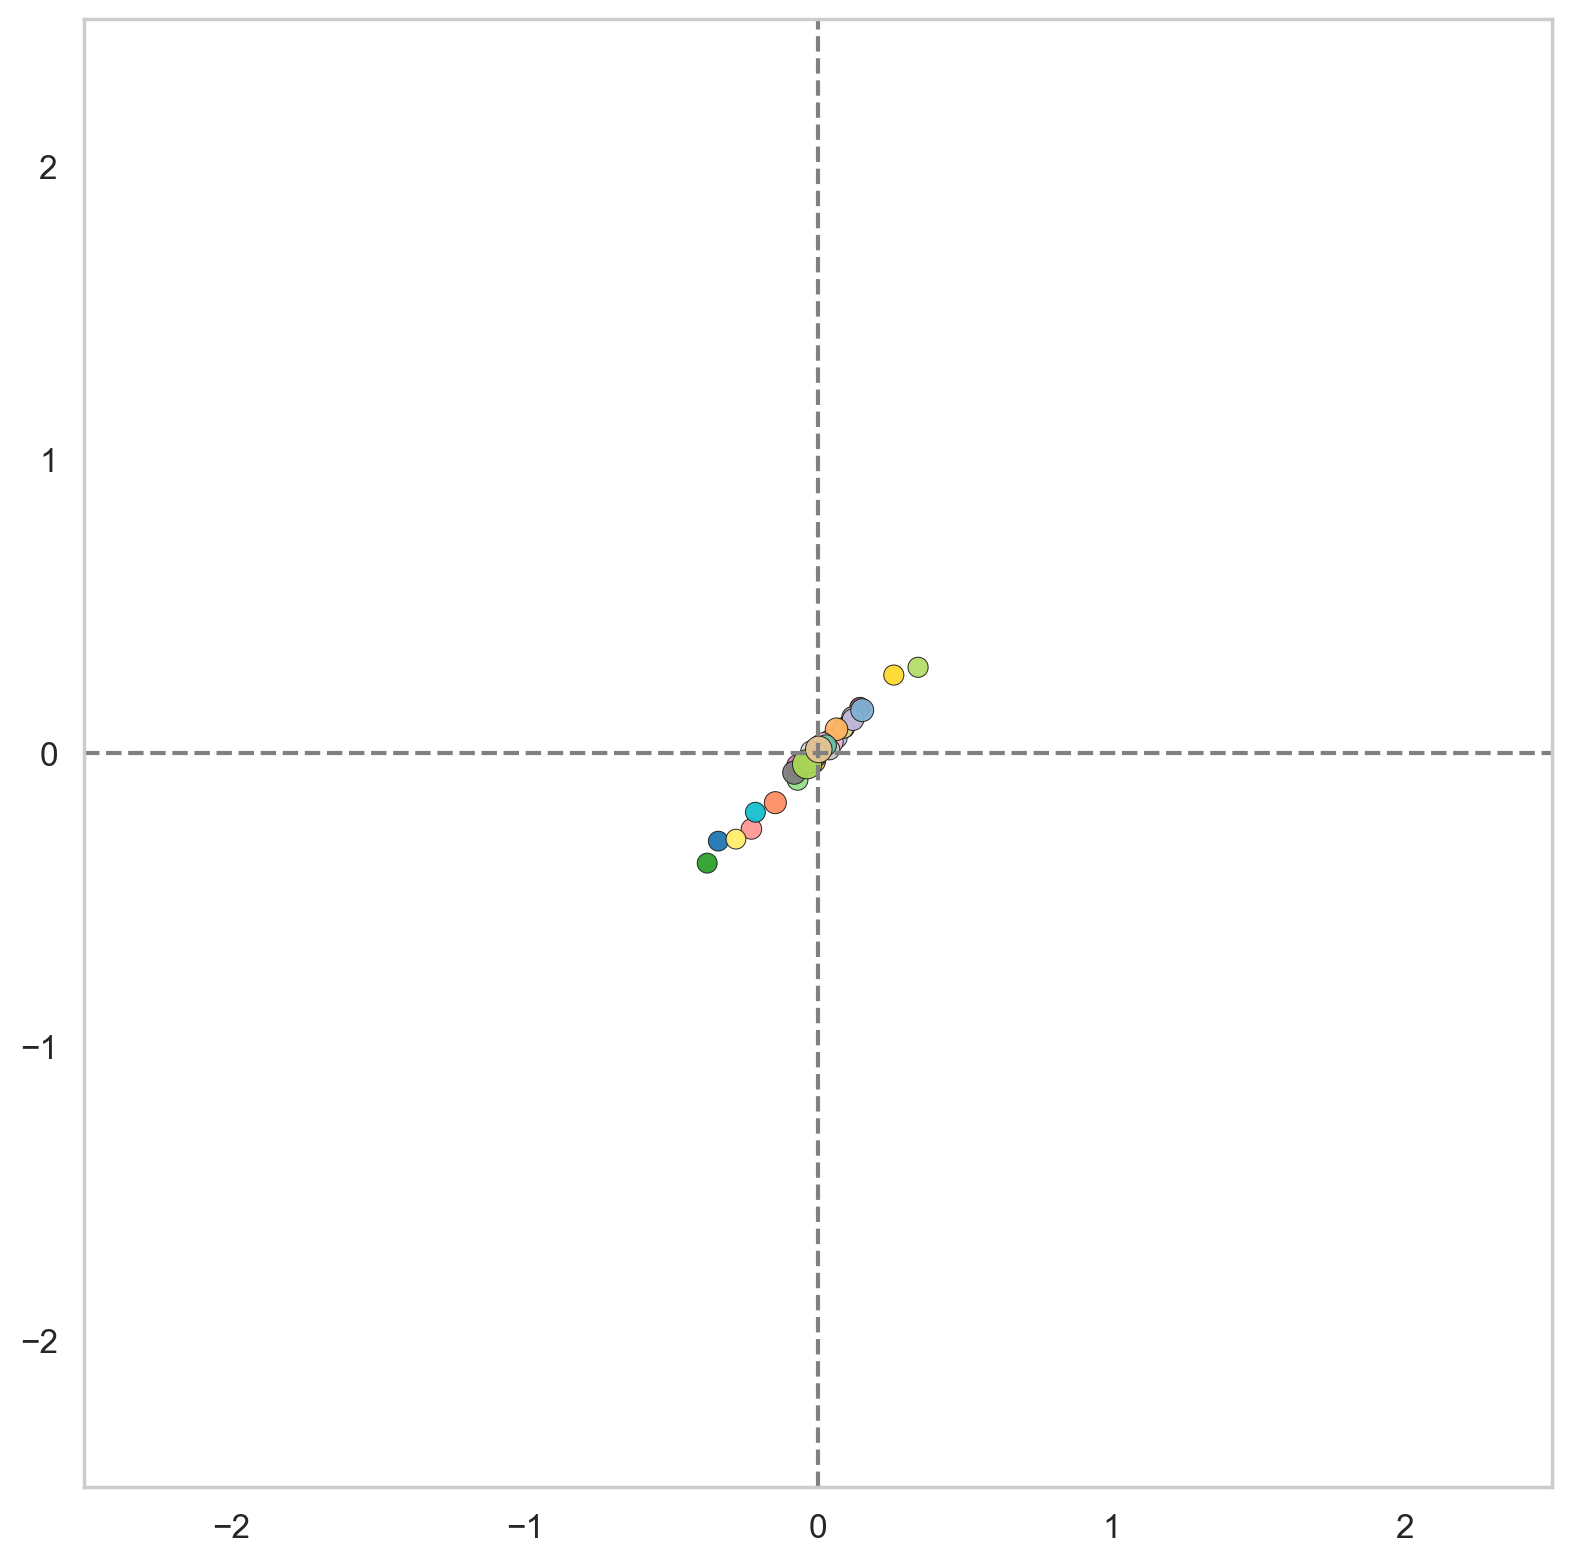

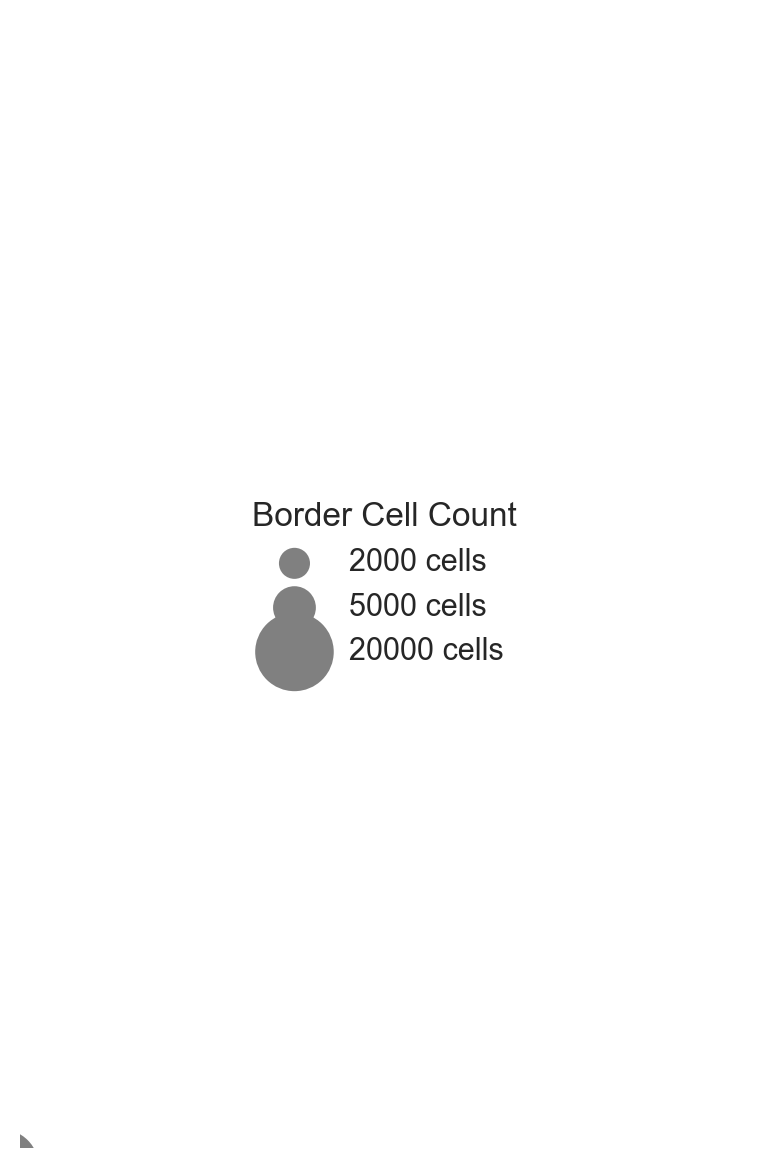

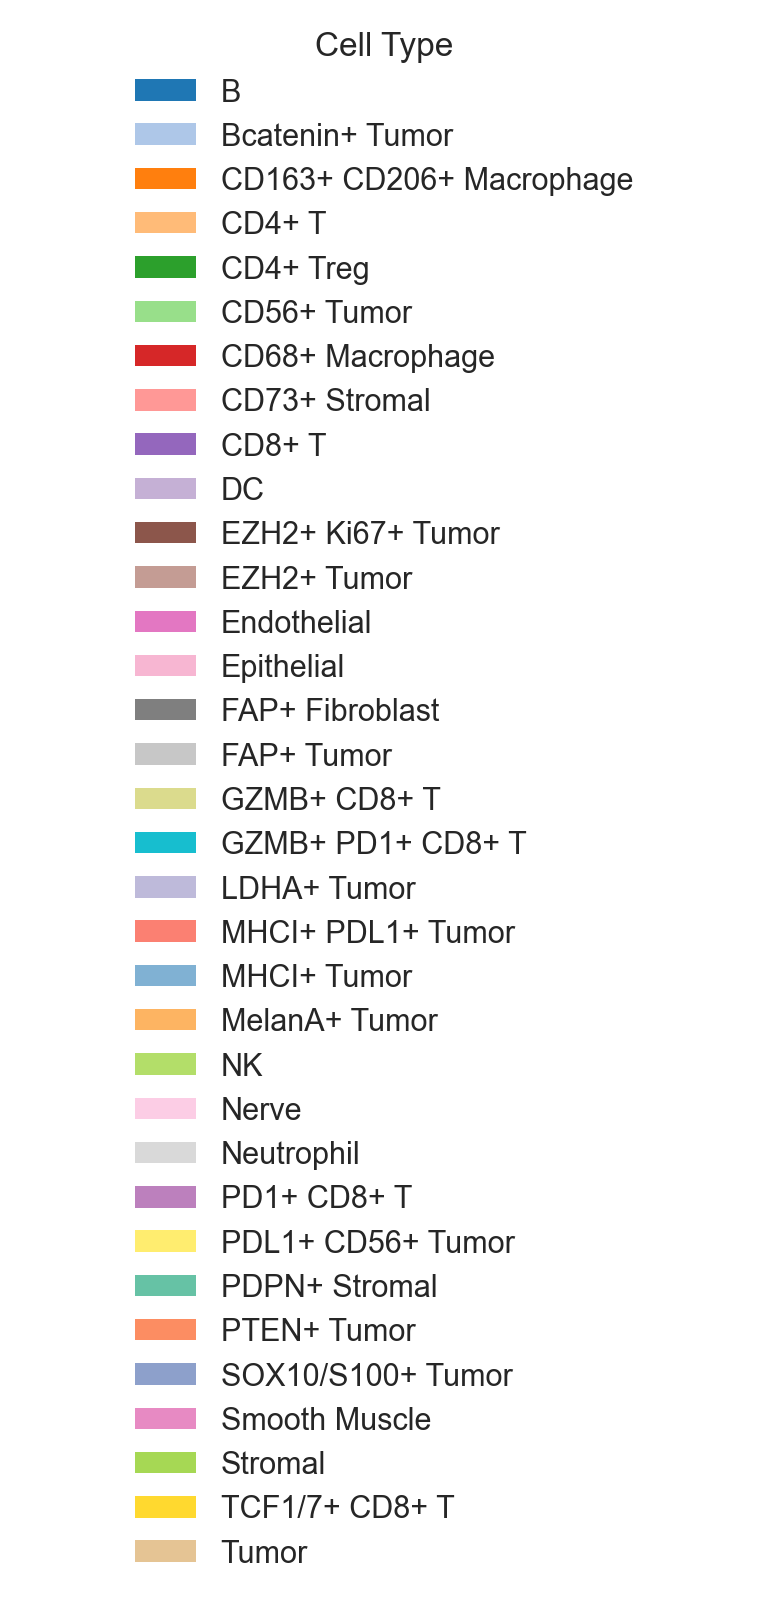

Done. Figures returned: (<Figure size 1600x1600 with 1 Axes>, <Figure size 800x1200 with 1 Axes>, <Figure size 800x1600 with 1 Axes>)


In [57]:
# run plot
figs = mg.pl.plot_border_enrichment(
    adata=cells_null,
    df_probabilities=perm_df,
    n1=N1,
    n2=N2,
    cell_type_col="Cell_Type",
    pos_threshold=0.25,              # plotting logic
    min_count=10,
    prob_key="neighborhood_probabilities",
    show=True,
    dpi=200,
    label_dots=False,
    label_fontsize=8,
    label_offset_frac=0.02,
    label_bbox=None,
    # neighborhood-count logic (separate from plotting)
    #neighborhoods_to_count=neighborhoods_example,
    neighborhood_count_threshold=0.15,
    use_tqdm_for_count=False,         # <-- NO progress bar
)

print("Done. Figures returned:", figs)

### Step 44. Quantify compositional similarity between shared-positive and single-positive states
Purpose: Compute Jensen-Shannon and cosine similarities so the overlap group can be compared numerically against each single-neighborhood population and their average.

User-adjustable inputs: You can swap in a different distance metric or a different neighborhood pair if you want to extend the comparison.

Expected output: Scalar similarity statistics that can be plotted or reported alongside the enrichment figures.

In [46]:
from scipy.spatial.distance import jensenshannon
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Get the distributions
border = pivot.loc[f"{n1} +\n{n2}"].values
single1 = pivot.loc[n1].values
single2 = pivot.loc[n2].values
avg = pivot.loc["Average"].values

# Small epsilon to avoid log(0)
eps = 1e-12
border = border + eps
single1 = single1 + eps
single2 = single2 + eps
avg = avg + eps

# Normalize to sum to 1
border /= border.sum()
single1 /= single1.sum()
single2 /= single2.sum()
avg /= avg.sum()

# --- Jensen–Shannon Divergence (JSD) ---
jsd1 = jensenshannon(border, single1)  # distance between border and CN1
jsd2 = jensenshannon(border, single2)  # border vs CN2
jsd_avg = jensenshannon(border, avg)   # border vs average

# Convert to similarity (1 - distance)
sim_jsd1 = 1 - jsd1
sim_jsd2 = 1 - jsd2
sim_jsd_avg = 1 - jsd_avg

# --- Cosine Similarity ---
sim_cos1 = cosine_similarity([border], [single1])[0,0]
sim_cos2 = cosine_similarity([border], [single2])[0,0]
sim_cos_avg = cosine_similarity([border], [avg])[0,0]

In [48]:
df

,Unnamed: 0,CCR7,CD103,CD11b,CD11c,CD138,CD15,CD163,CD20,CD206,...,CD38,filename,region,x,y,Cell_Type,Overall_Cell_Type,Neighborhood,Count_Above_Threshold,Region
0,0,-0.362926,-0.729925,-0.150820,-0.363121,-0.193573,-0.376392,-0.277710,-0.096556,-0.326673,...,NaN,21_06_23_reg001.tsv,2,3981,47146,CD73+ Stromal,Stromal,Stromal Enriched,1,21_06_23_reg001.tsv
1,1,-0.542319,-0.723530,-0.193650,-0.359325,-0.199382,-0.394698,-0.219857,-0.126534,-0.333797,...,NaN,21_06_23_reg001.tsv,2,5286,39373,CD73+ Stromal,Stromal,Stromal Enriched,1,21_06_23_reg001.tsv
2,2,-0.444684,-0.497128,-0.329550,-0.292091,-0.201171,-0.202878,-0.309667,-0.135984,-0.347450,...,NaN,21_06_23_reg001.tsv,2,22899,42306,Endothelial,Stromal,Vasculature,1,21_06_23_reg001.tsv
3,3,-0.829088,-1.629941,-0.341772,-0.380618,-0.255592,-0.419650,-0.115570,-0.118611,0.245775,...,NaN,21_06_23_reg001.tsv,2,5747,45479,CD73+ Stromal,Stromal,Stromal Enriched,1,21_06_23_reg001.tsv
4,4,0.111211,-0.134976,3.659562,0.540194,-0.181382,5.446553,-0.212632,-0.125781,-0.246451,...,NaN,21_06_23_reg001.tsv,2,17460,49393,Neutrophil,Immune,Neutrophil Enriched,1,21_06_23_reg001.tsv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,5019154,0.098215,-0.083622,-0.217149,-0.437058,-0.297181,-0.058682,-0.292474,-0.041080,-0.335148,...,-0.723163,23_07_06_reg002.tsv,2,4283,6987,Stromal,Stromal,Proliferating Tumor,1,23_07_06_reg002.tsv
5019155,5019155,-0.240248,-0.113821,-0.464631,-0.433815,-0.275257,-0.066953,-0.282331,-0.028372,-0.194535,...,-0.350178,23_07_06_reg002.tsv,2,17172,6095,MelanA+ Tumor,Tumor,Stromal Enriched,1,23_07_06_reg002.tsv
5019156,5019156,-0.423292,-0.166772,-0.623979,-0.435652,-0.300200,-0.055559,-0.314097,-0.139452,-0.301023,...,-0.099238,23_07_06_reg002.tsv,2,16878,4870,Stromal,Stromal,Stromal Enriched,1,23_07_06_reg002.tsv
5019157,5019157,1.402914,0.407268,1.345068,-0.353550,-0.301476,-0.048187,1.235023,-0.134024,0.436833,...,-0.057958,23_07_06_reg002.tsv,2,13326,10841,Tumor,Tumor,Macrophage Enriched Immune,1,23_07_06_reg002.tsv


### Step 47. Reinspect the probability table before spatial overlap analysis
Purpose: Preview `probabilities_df` to confirm the neighborhood names and metadata columns used in the manual overlap calculations.

User-adjustable inputs: No parameters change here.

Expected output: A table preview of the probability matrix with attached metadata.

In [49]:
probabilities_df

,Stromal Enriched,Vasculature,Neutrophil Enriched,Macrophage Enriched Immune,Vasculature & Immune,Productive T cell & Tumor,Proliferating Tumor,Inflamed Tumor,Tumor & Immune,Epithelial/Skin Appendages,...,Follicle,Perivascular,Immune Infiltrate,DC Enriched Immune,Cell_Type,filename,Count_Above_Threshold,x,y,is_border
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,CD73+ Stromal,21_06_23_reg001.tsv,1,3981,47146,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,CD73+ Stromal,21_06_23_reg001.tsv,1,5286,39373,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,Endothelial,21_06_23_reg001.tsv,1,22899,42306,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,CD73+ Stromal,21_06_23_reg001.tsv,1,5747,45479,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,Neutrophil,21_06_23_reg001.tsv,1,17460,49393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,Stromal,23_07_06_reg002.tsv,1,4283,6987,0
5019155,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,MelanA+ Tumor,23_07_06_reg002.tsv,1,17172,6095,0
5019156,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,Stromal,23_07_06_reg002.tsv,1,16878,4870,0
5019157,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,Tumor,23_07_06_reg002.tsv,1,13326,10841,0


### Step 48. Ensure `probabilities_df` carries the spatial coordinates
Purpose: Copy `x`, `y`, and `filename` into the probability table so the manual overlap calculations and spatial plots can work from a single DataFrame.

User-adjustable inputs: Update the source column names if your dataset stores coordinates or region IDs under different names.

Expected output: The probability table now carries the minimal spatial metadata required for the remaining custom plots.

In [50]:
probabilities_df["x"] = cells.obs["x"].to_numpy()
probabilities_df["y"] = cells.obs["y"].to_numpy()
probabilities_df["filename"] = cells.obs["filename"].to_numpy()

### Step 49. Confirm the available region labels
Purpose: Display the `filename` column to check which region names are available for the manual spatial overlap analysis.

User-adjustable inputs: No parameters change here.

Expected output: A list-like preview of region identifiers.

In [51]:
probabilities_df['filename']

0          21_06_23_reg001.tsv
1          21_06_23_reg001.tsv
2          21_06_23_reg001.tsv
3          21_06_23_reg001.tsv
4          21_06_23_reg001.tsv
                  ...         
5019154    23_07_06_reg002.tsv
5019155    23_07_06_reg002.tsv
5019156    23_07_06_reg002.tsv
5019157    23_07_06_reg002.tsv
5019158    23_07_06_reg002.tsv
Name: filename, Length: 5019159, dtype: object

### Step 50. Preview the raw neighborhood probability matrix
Purpose: Inspect the stored probability matrix directly from `cells.obsm` before building manual masks for one region and one neighborhood pair.

User-adjustable inputs: This is a QC step with no tunable parameters.

Expected output: The raw probability array used by the manual overlap calculations.

In [52]:
cells.obsm['neighborhood_probabilities']

array([[1.00000000e+000, 9.82284411e-177, 1.71815932e-096, ...,
        4.08738399e-081, 6.45786102e-091, 1.79437805e-185],
       [1.00000000e+000, 2.39527978e-058, 8.29449260e-035, ...,
        1.05229702e-025, 9.02313104e-042, 1.30662924e-067],
       [1.66322705e-084, 9.99988811e-001, 5.23353016e-030, ...,
        2.77108062e-086, 5.63069216e-021, 3.52342691e-026],
       ...,
       [1.00000000e+000, 3.40925996e-024, 1.98361174e-022, ...,
        6.09723303e-012, 1.18186773e-032, 1.26695168e-038],
       [9.99958684e-001, 2.68355761e-012, 2.90610827e-008, ...,
        3.51521752e-005, 2.54490780e-013, 4.07754033e-016],
       [1.70649755e-044, 2.23458132e-056, 0.00000000e+000, ...,
        0.00000000e+000, 6.38206390e-253, 2.42907785e-145]])

### Step 51. Build manual masks for one region and one neighborhood pair
Purpose: Extract the coordinates and probability vectors for a single region so you can inspect the logic behind the packaged `spatial_loc_region` helper.

User-adjustable inputs: Change `region`, `n1`, and `n2` to explore a different local interface.

Expected output: Region-specific coordinate arrays and neighborhood-probability vectors for manual plotting or debugging.

In [53]:
region = "05_06_23_reg003.tsv"
n1, n2 = "Inflamed Tumor", "Productive T cell & Tumor"

region_mask = cells.obs["filename"].astype(str).eq(region).to_numpy()

# coords from obs
x = cells.obs.loc[region_mask, "x"].to_numpy()
y = cells.obs.loc[region_mask, "y"].to_numpy()

# neighborhood probabilities from probabilities_df
p1 = probabilities_df.loc[region_mask, n1].to_numpy()
p2 = probabilities_df.loc[region_mask, n2].to_numpy()

### Step 52. Reinspect the raw probability matrix
Purpose: Display the underlying probability matrix again as a checkpoint before the threshold sweep.

User-adjustable inputs: No arguments are changed here.

Expected output: A reminder of the raw matrix structure used by the final spatial helper.

In [54]:
cells.obsm['neighborhood_probabilities']

array([[1.00000000e+000, 9.82284411e-177, 1.71815932e-096, ...,
        4.08738399e-081, 6.45786102e-091, 1.79437805e-185],
       [1.00000000e+000, 2.39527978e-058, 8.29449260e-035, ...,
        1.05229702e-025, 9.02313104e-042, 1.30662924e-067],
       [1.66322705e-084, 9.99988811e-001, 5.23353016e-030, ...,
        2.77108062e-086, 5.63069216e-021, 3.52342691e-026],
       ...,
       [1.00000000e+000, 3.40925996e-024, 1.98361174e-022, ...,
        6.09723303e-012, 1.18186773e-032, 1.26695168e-038],
       [9.99958684e-001, 2.68355761e-012, 2.90610827e-008, ...,
        3.51521752e-005, 2.54490780e-013, 4.07754033e-016],
       [1.70649755e-044, 2.23458132e-056, 0.00000000e+000, ...,
        0.00000000e+000, 6.38206390e-253, 2.42907785e-145]])

### Step 53. Reinspect the observation metadata before the threshold sweep
Purpose: Preview the observation table one last time before iterating across thresholds in the packaged spatial overlap function.

User-adjustable inputs: No user-facing parameters change here.

Expected output: A final QC view of the metadata.

In [55]:
cells.obs

,Unnamed: 0,CCR7,CD103,CD11b,CD11c,CD138,CD15,CD163,CD20,CD206,...,CD38,filename,region,x,y,Cell_Type,Overall_Cell_Type,Neighborhood,Count_Above_Threshold,Region
0,0,-0.362926,-0.729925,-0.150820,-0.363121,-0.193573,-0.376392,-0.277710,-0.096556,-0.326673,...,NaN,21_06_23_reg001.tsv,2,3981,47146,CD73+ Stromal,Stromal,Stromal Enriched,1,21_06_23_reg001.tsv
1,1,-0.542319,-0.723530,-0.193650,-0.359325,-0.199382,-0.394698,-0.219857,-0.126534,-0.333797,...,NaN,21_06_23_reg001.tsv,2,5286,39373,CD73+ Stromal,Stromal,Stromal Enriched,1,21_06_23_reg001.tsv
2,2,-0.444684,-0.497128,-0.329550,-0.292091,-0.201171,-0.202878,-0.309667,-0.135984,-0.347450,...,NaN,21_06_23_reg001.tsv,2,22899,42306,Endothelial,Stromal,Vasculature,1,21_06_23_reg001.tsv
3,3,-0.829088,-1.629941,-0.341772,-0.380618,-0.255592,-0.419650,-0.115570,-0.118611,0.245775,...,NaN,21_06_23_reg001.tsv,2,5747,45479,CD73+ Stromal,Stromal,Stromal Enriched,1,21_06_23_reg001.tsv
4,4,0.111211,-0.134976,3.659562,0.540194,-0.181382,5.446553,-0.212632,-0.125781,-0.246451,...,NaN,21_06_23_reg001.tsv,2,17460,49393,Neutrophil,Immune,Neutrophil Enriched,1,21_06_23_reg001.tsv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019154,5019154,0.098215,-0.083622,-0.217149,-0.437058,-0.297181,-0.058682,-0.292474,-0.041080,-0.335148,...,-0.723163,23_07_06_reg002.tsv,2,4283,6987,Stromal,Stromal,Proliferating Tumor,1,23_07_06_reg002.tsv
5019155,5019155,-0.240248,-0.113821,-0.464631,-0.433815,-0.275257,-0.066953,-0.282331,-0.028372,-0.194535,...,-0.350178,23_07_06_reg002.tsv,2,17172,6095,MelanA+ Tumor,Tumor,Stromal Enriched,1,23_07_06_reg002.tsv
5019156,5019156,-0.423292,-0.166772,-0.623979,-0.435652,-0.300200,-0.055559,-0.314097,-0.139452,-0.301023,...,-0.099238,23_07_06_reg002.tsv,2,16878,4870,Stromal,Stromal,Stromal Enriched,1,23_07_06_reg002.tsv
5019157,5019157,1.402914,0.407268,1.345068,-0.353550,-0.301476,-0.048187,1.235023,-0.134024,0.436833,...,-0.057958,23_07_06_reg002.tsv,2,13326,10841,Tumor,Tumor,Macrophage Enriched Immune,1,23_07_06_reg002.tsv


### Step 54. Sweep the spatial overlap helper across thresholds
Purpose: Run `mg.pl.spatial_loc_region` from `src/mingl/pl/spatial_location_reg.py` at multiple thresholds to show how sensitive the shared-positive border pattern is to the positivity cutoff.

User-adjustable inputs: Important parameters are `region`, `n1`, `n2`, `threshold`, `region_key`, coordinate columns, marker sizes, and colors. The threshold is the main biological sensitivity parameter in this block.

Expected output: A series of spatial overlap maps that make the threshold dependence explicit.

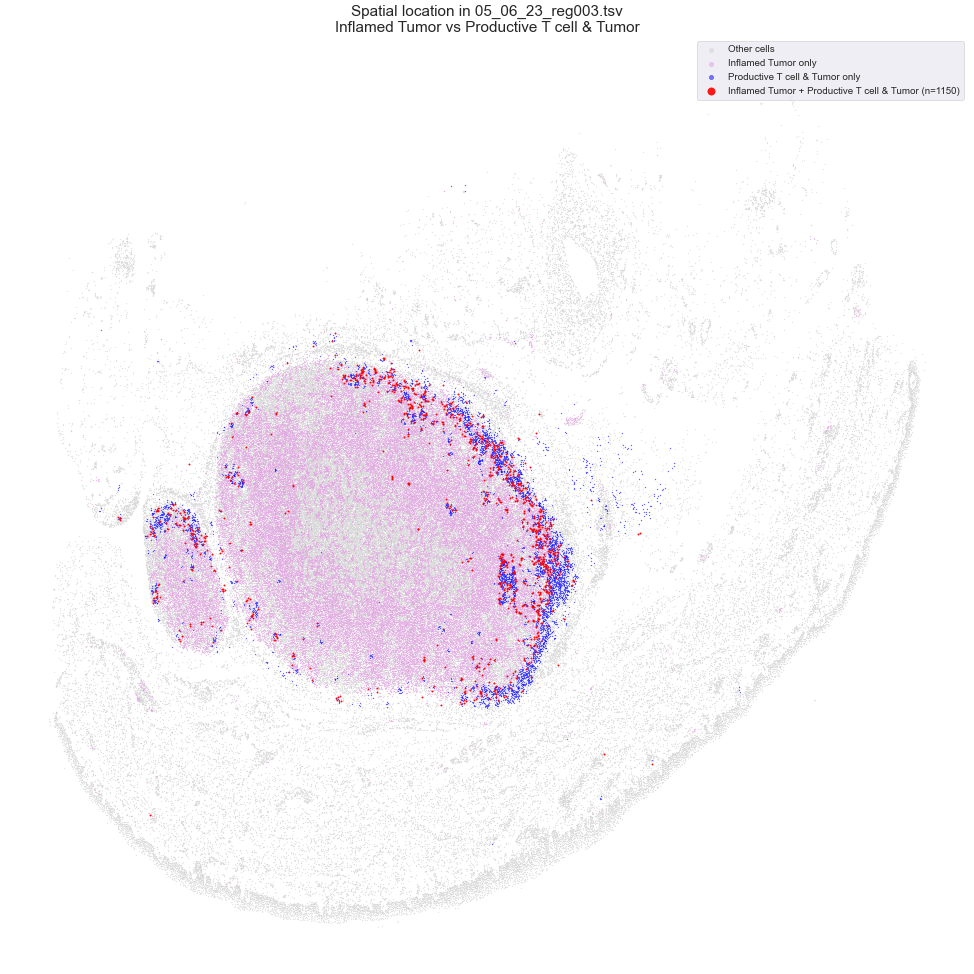

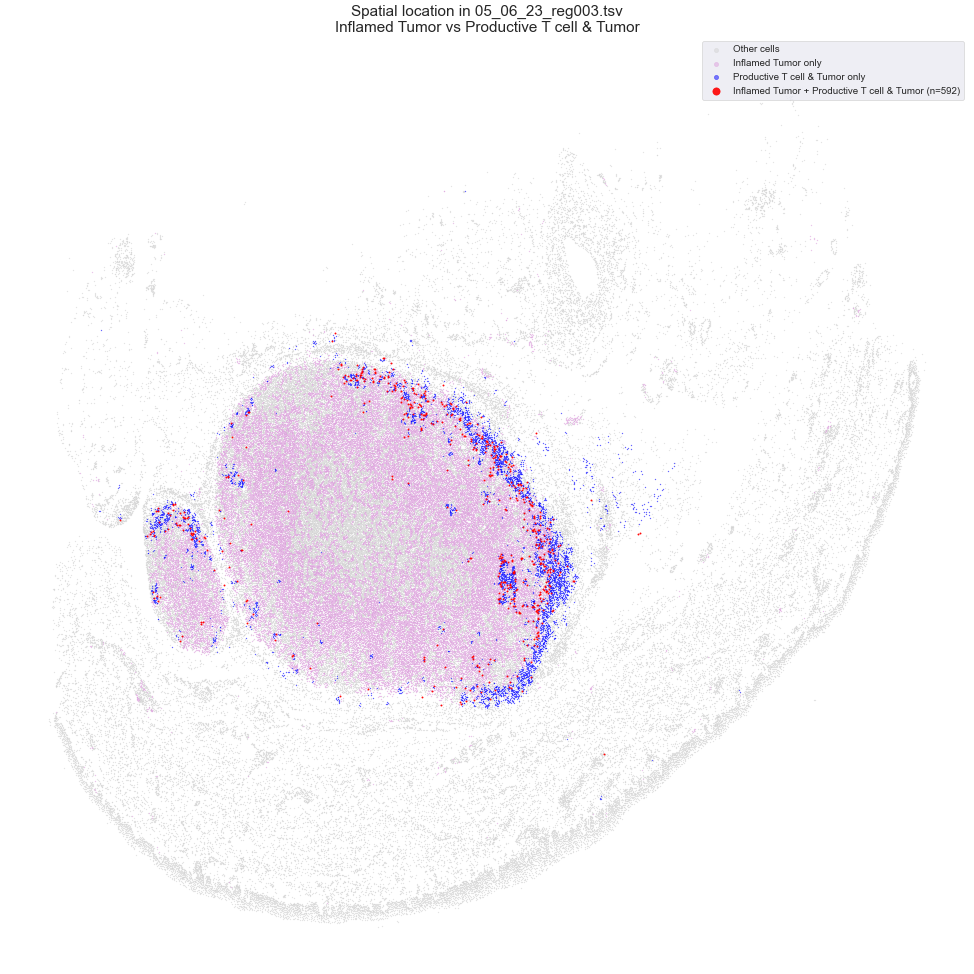

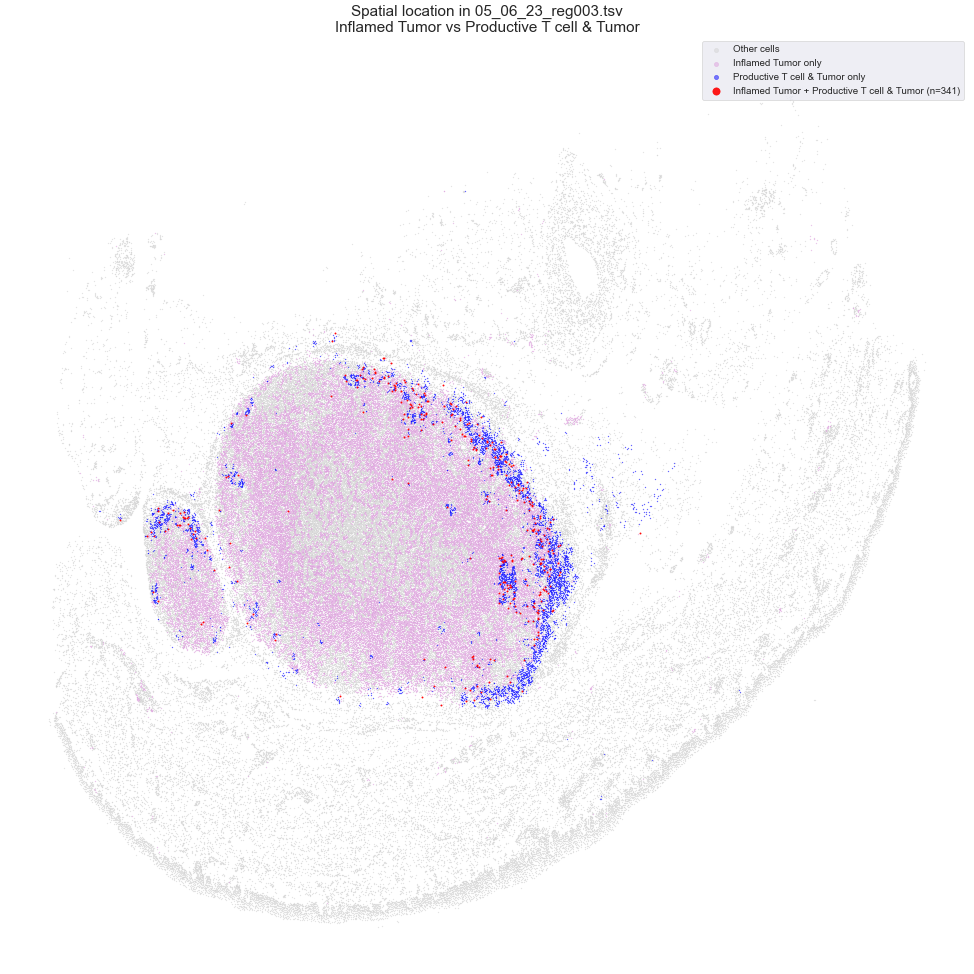

In [56]:
thresholds = [0.05, 0.15, 0.25]
for i in thresholds:
    fig, ax, masks = mg.pl.spatial_loc_region(
        cells,
        region= "05_06_23_reg003.tsv",#"14_06_23_reg002.tsv",
        n1="Inflamed Tumor",
        n2="Productive T cell & Tumor",
        threshold=i,
    )


### Step 55. Summarize threshold sensitivity as a stacked area plot
Purpose: Quantify how the cell-type composition of shared-positive border cells changes as the positivity threshold is varied across the chosen range.

User-adjustable inputs: Change `thresholds`, `n1`, `n2`, or the visualization settings to test alternative definitions of the border state.

Expected output: A compact summary plot showing which cell types remain stable or shift as the threshold changes.

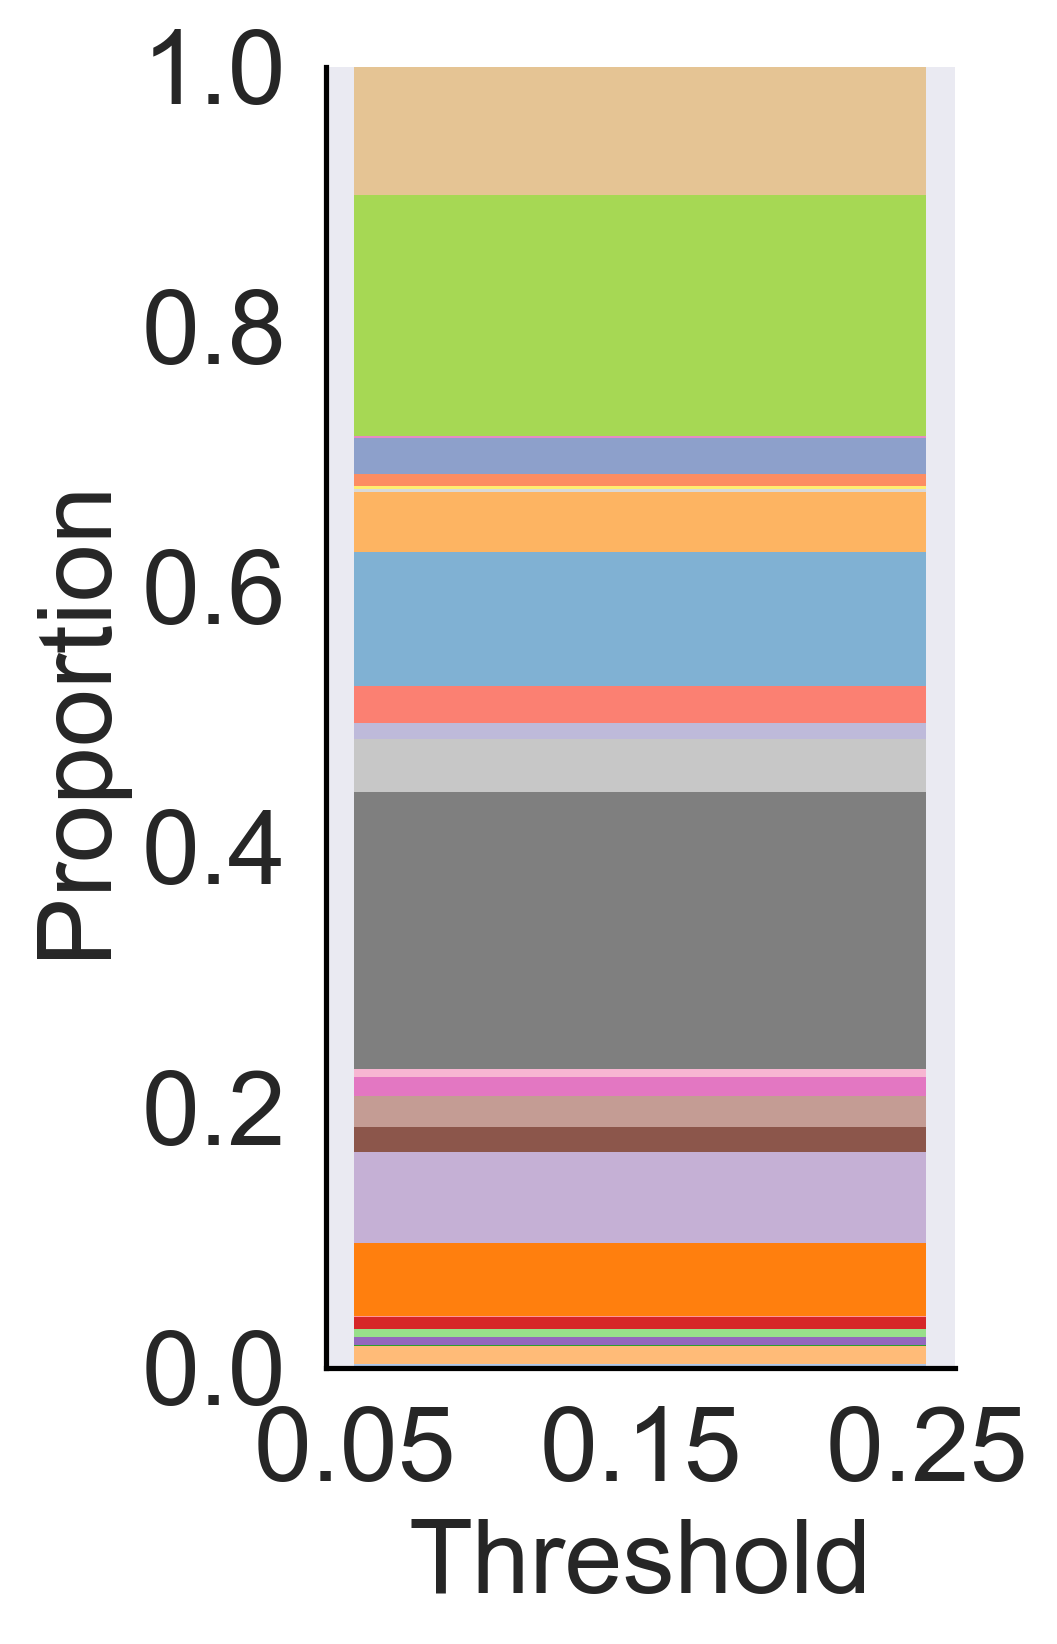

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Neighborhoods
n1, n2 = "Inflamed Tumor", "Productive T cell & Tumor"

# Thresholds to test
thresholds = [0.05, 0.15, 0.25]

# Store results
results = []

for threshold in thresholds:

    # Define masks across ALL cells
    pos_1 = probabilities_df[n1] > threshold
    pos_2 = probabilities_df[n2] > threshold
    mask_both = pos_1 & pos_2

    df_border = probabilities_df[mask_both]

    border_count = len(df_border)

    # Skip threshold if no border cells
    if border_count == 0:
        continue

    # Compute cell type proportions among border cells
    proportions = (
        df_border["Cell_Type"]
        .value_counts(normalize=True)
        .rename_axis("Cell_Type")
        .reset_index(name="Proportion")
    )

    proportions["Threshold"] = threshold
    proportions["Border_Count"] = border_count

    results.append(proportions)

# Combine results
df_prop = pd.concat(results, ignore_index=True)

# Pivot to wide format
pivot = (
    df_prop
    .pivot(index="Threshold", columns="Cell_Type", values="Proportion")
    .fillna(0)
    .sort_index()
)

# --- Area Plot ---
fig, ax = plt.subplots(figsize=(4, 6), dpi=300)

colors = [color_dict.get(ct, "#cccccc") for ct in pivot.columns]

ax.stackplot(
    pivot.index,
    pivot.T.values,
    labels=pivot.columns,
    colors=colors,
    linewidth=0,          # remove edge lines
    edgecolor='none'      # ensure no white borders
)

# Explicit x ticks
ax.set_xticks(thresholds)
ax.set_xticklabels([f"{t:.2f}" for t in thresholds], fontsize=25)
ax.tick_params(axis='y', labelsize=25)

ax.set_xlabel("Threshold", fontsize=25)
ax.set_ylabel("Proportion", fontsize=25)
ax.set_ylim(0, 1)
ax.grid(False)

# Keep only left & bottom spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Make remaining spines black
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

plt.tight_layout()
plt.show()

swap cn1 and cn2 cell type labels (including border cells) and plot enrichment of cell types

c:\Users\k1van\Mingl\testing-mingl-matched\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


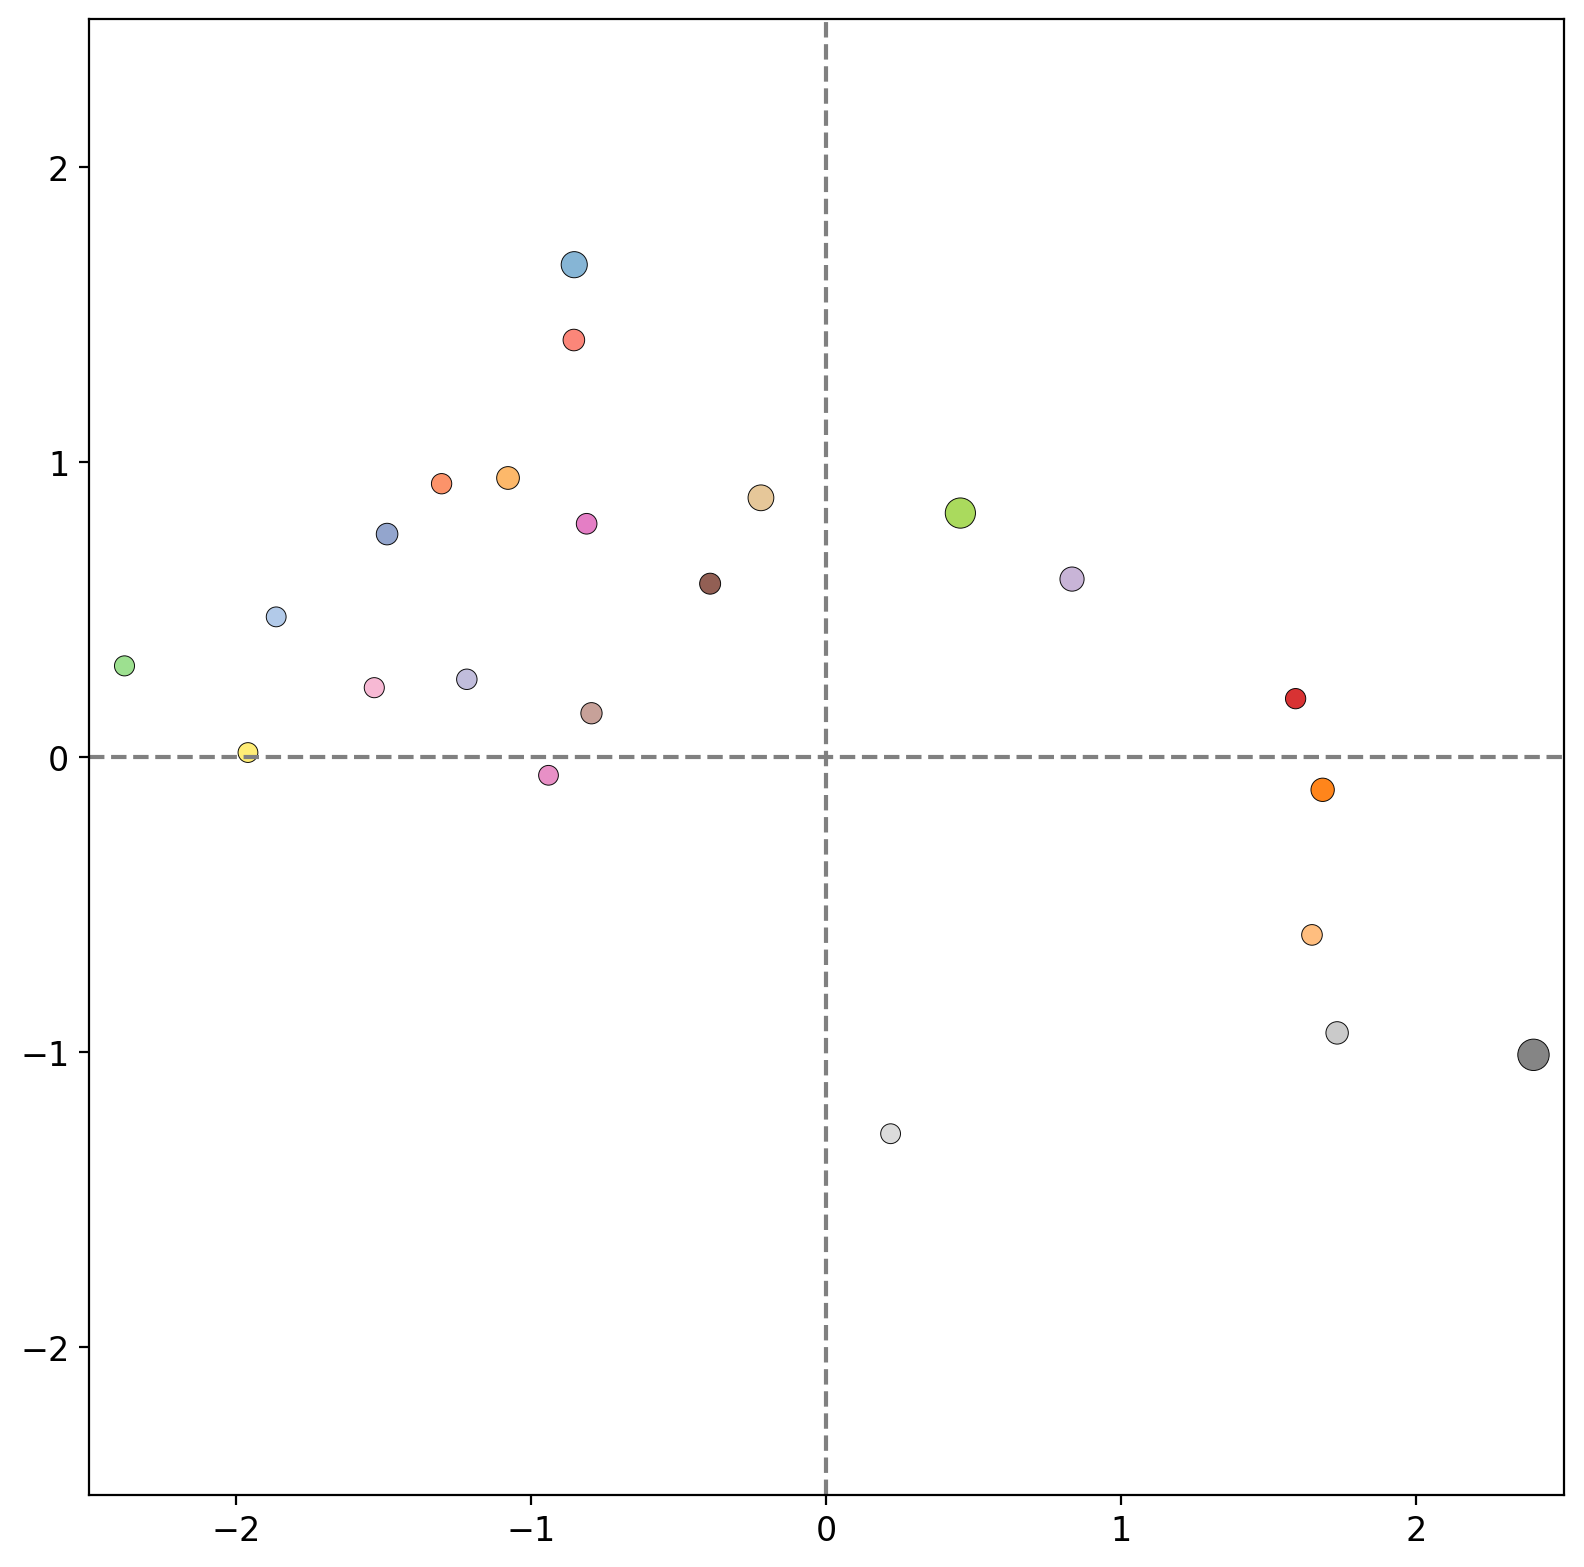

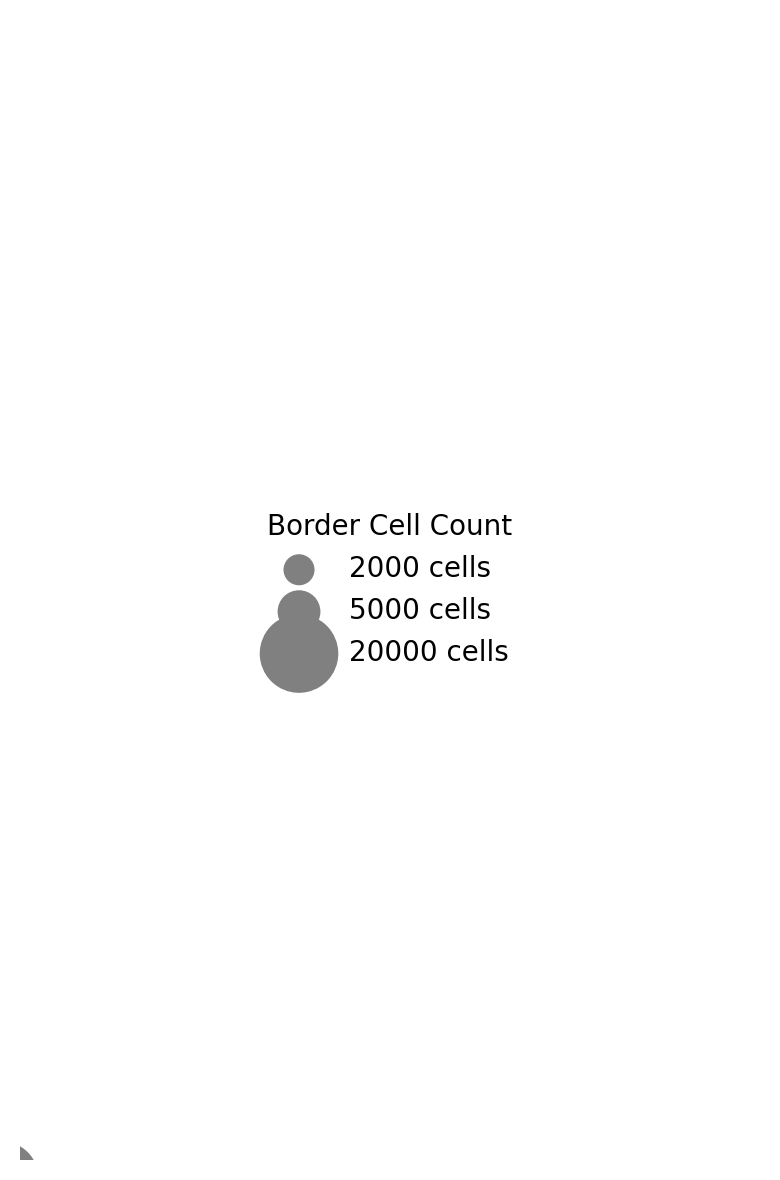

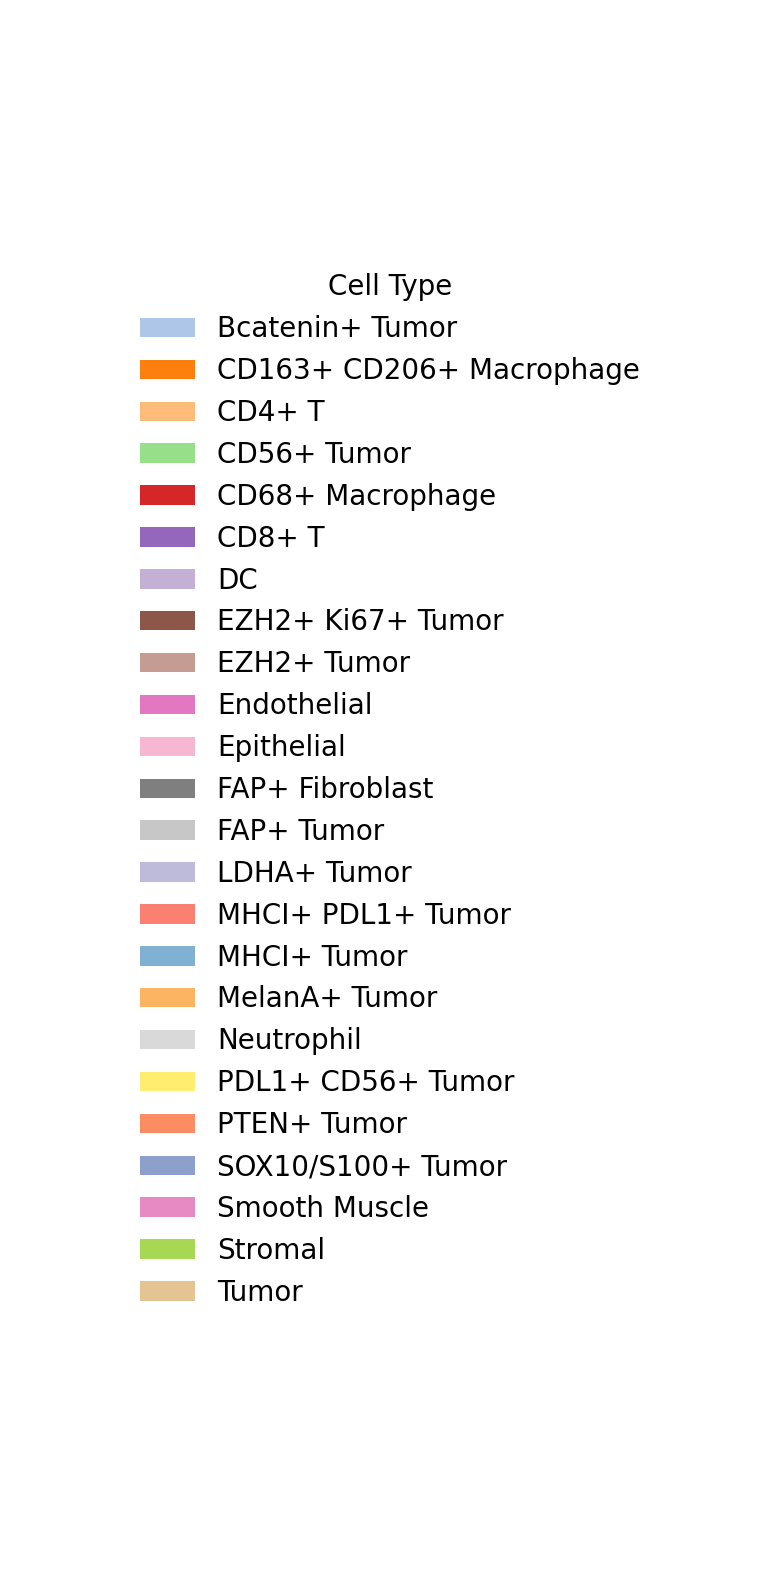

Observed enrichment plot complete.
CN1-positive cells: 772,492
CN2-positive cells: 360,491
CN1/CN2 interface universe: 1,123,219
CN1/CN2 border cells: 9,764


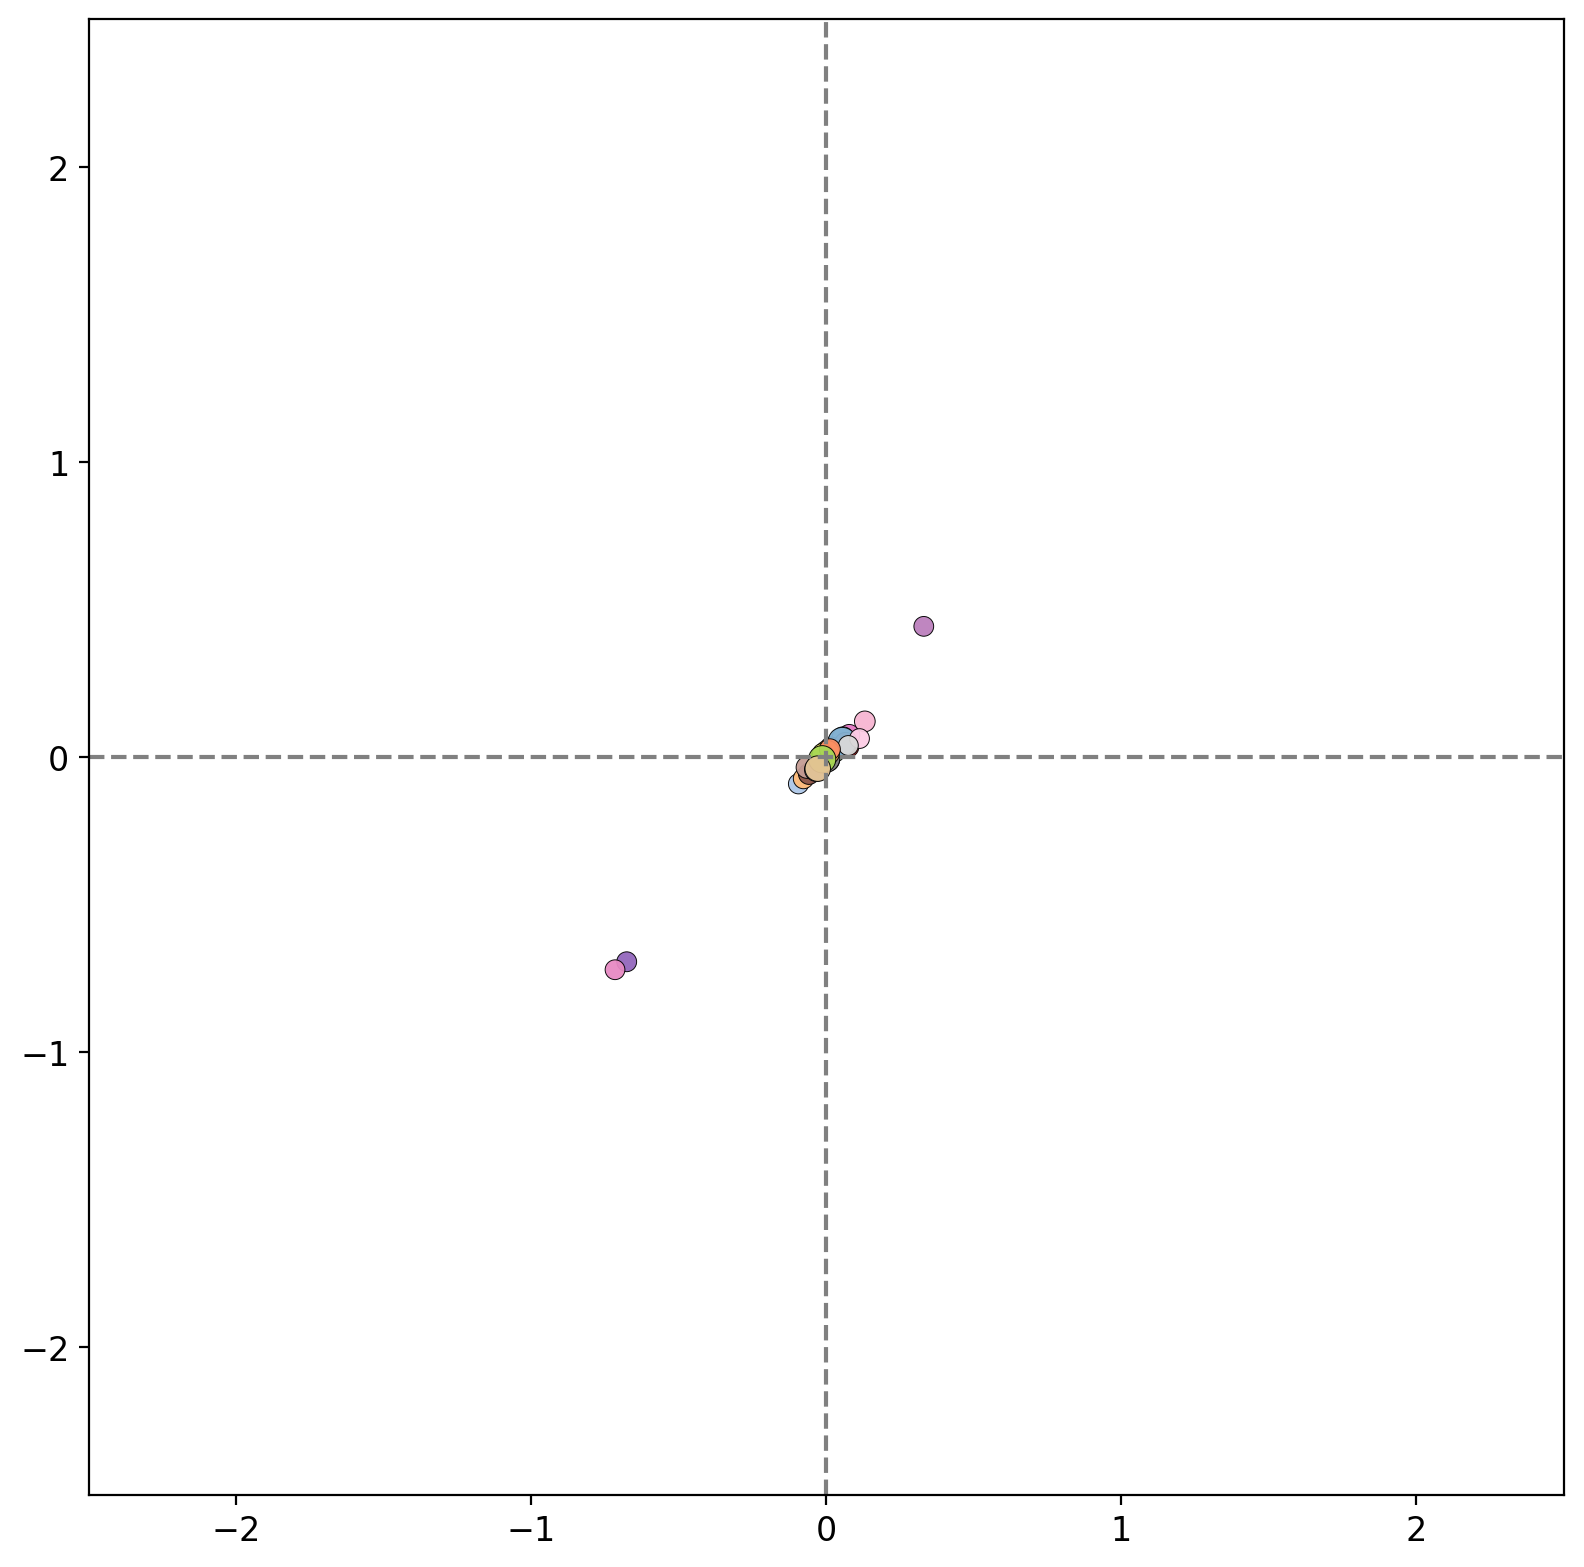

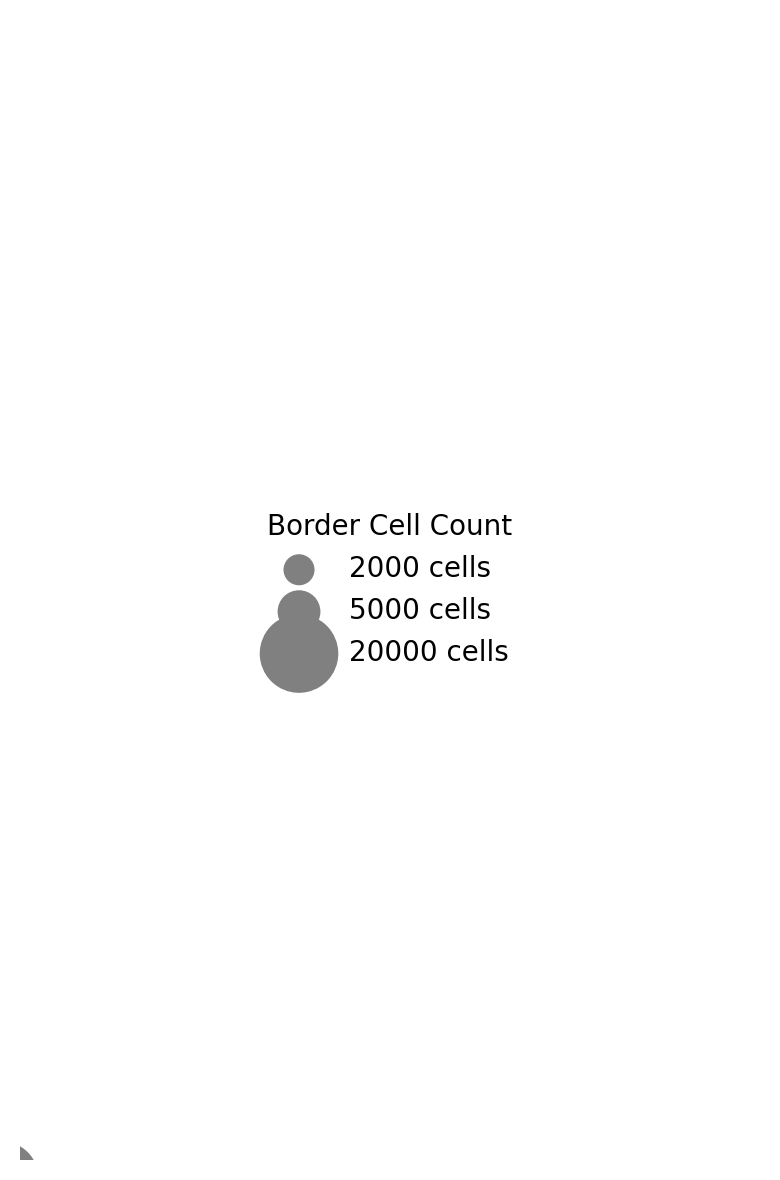

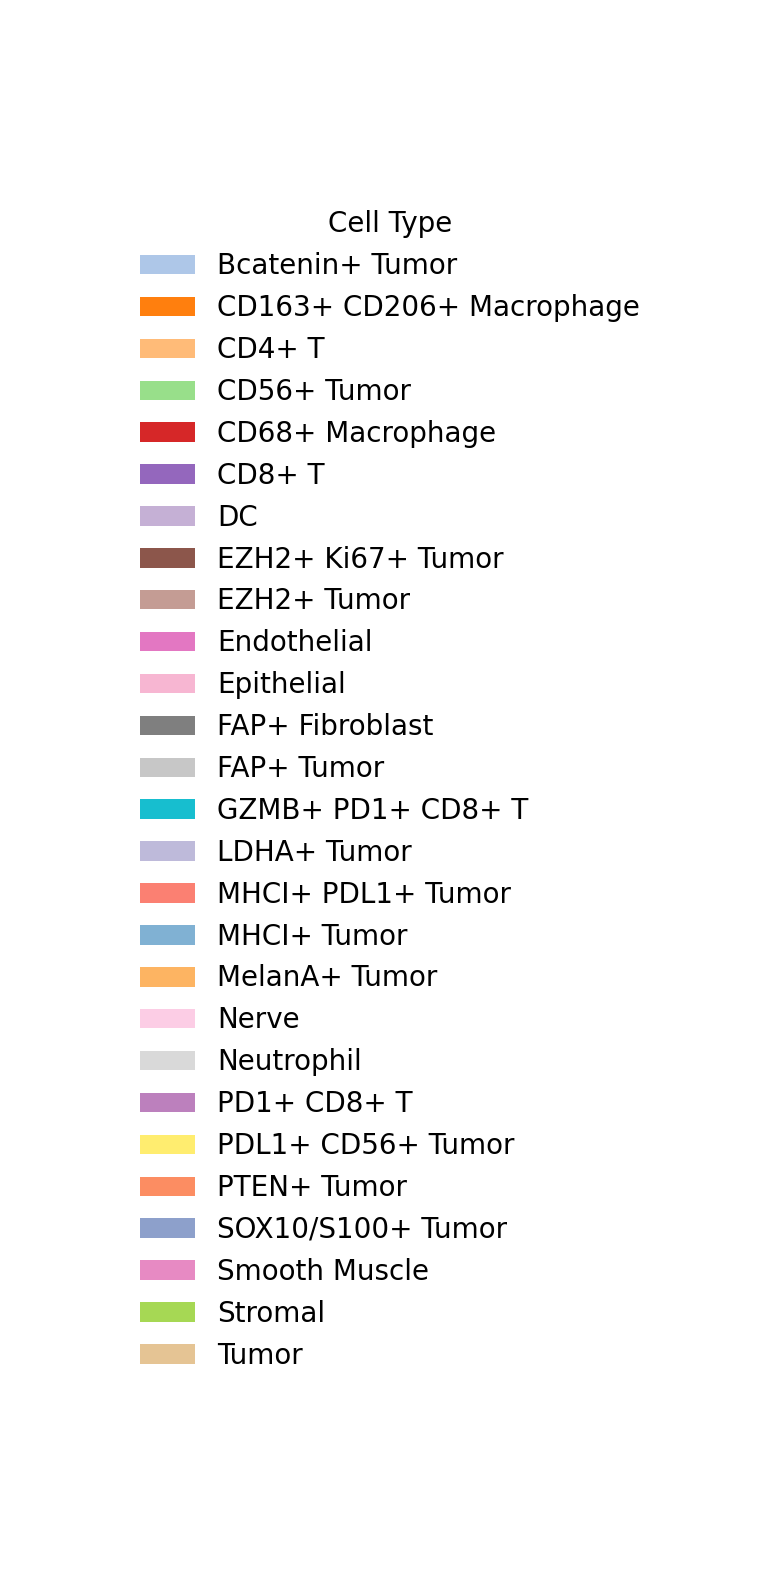

One shuffled-null enrichment plot complete.


In [10]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import mingl as mg


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
N1 = "Inflamed Tumor"
N2 = "Productive T cell & Tumor"

probability_threshold = 0.25
n_perm = 1000
rng = np.random.default_rng(42)


# ------------------------------------------------------------
# Add cell-type annotations to the probability dataframe
# ------------------------------------------------------------
assert probabilities_df.index.equals(cells.obs_names), (
    "probabilities_df and cells.obs must have matching cell order."
)

assert "Cell_Type" in cells.obs.columns, (
    "Could not find 'Cell_Type' in cells.obs."
)

assert N1 in probabilities_df.columns, f"{N1!r} not found in probability columns."
assert N2 in probabilities_df.columns, f"{N2!r} not found in probability columns."

probabilities_df["Cell_Type"] = cells.obs["Cell_Type"].to_numpy()


# ------------------------------------------------------------
# Observed enrichment plot
# ------------------------------------------------------------
figs_observed = mg.pl.plot_border_enrichment(
    adata=cells,
    df_probabilities=probabilities_df,
    n1=N1,
    n2=N2,
    cell_type_col="Cell_Type",
    pos_threshold=probability_threshold,
    min_count=10,
    prob_key="neighborhood_probabilities",
    neighborhood_count_threshold=0.15,
    use_tqdm_for_count=False,
    show=True,
    dpi=200,
    label_dots=False,
    label_fontsize=8,
    label_offset_frac=0.02,
    label_bbox=None,
)

print("Observed enrichment plot complete.")


# ------------------------------------------------------------
# Define the permutation universe
#
# This includes every cell positive for CN1 OR CN2:
# CN1-only cells, CN2-only cells, and CN1/CN2 border cells.
# Each border cell occurs only once because this is a union.
# ------------------------------------------------------------
cn1_positive = probabilities_df[N1] >= probability_threshold
cn2_positive = probabilities_df[N2] >= probability_threshold
interface_mask = cn1_positive | cn2_positive

print(f"CN1-positive cells: {cn1_positive.sum():,}")
print(f"CN2-positive cells: {cn2_positive.sum():,}")
print(f"CN1/CN2 interface universe: {interface_mask.sum():,}")
print(f"CN1/CN2 border cells: {(cn1_positive & cn2_positive).sum():,}")


# ------------------------------------------------------------
# Sanity-check: plot ONE shuffled null example first
# ------------------------------------------------------------
perm_df_example = probabilities_df.copy()

perm_df_example.loc[interface_mask, "Cell_Type"] = rng.permutation(
    probabilities_df.loc[interface_mask, "Cell_Type"].to_numpy()
)

cells_null_example = cells.copy()
cells_null_example.obs["Cell_Type"] = perm_df_example["Cell_Type"].to_numpy()

figs_null_example = mg.pl.plot_border_enrichment(
    adata=cells_null_example,
    df_probabilities=perm_df_example,
    n1=N1,
    n2=N2,
    cell_type_col="Cell_Type",
    pos_threshold=probability_threshold,
    min_count=10,
    prob_key="neighborhood_probabilities",
    neighborhood_count_threshold=0.15,
    use_tqdm_for_count=False,
    show=True,
    dpi=200,
    label_dots=False,
    label_fontsize=8,
    label_offset_frac=0.02,
    label_bbox=None,
)

print("One shuffled-null enrichment plot complete.")

In [11]:
import inspect

print(inspect.getsource(mg.pl.plot_border_enrichment))

def plot_border_enrichment(
    *,
    adata: Optional[AnnData] = None,
    df_probabilities: Optional[pd.DataFrame] = None,
    n1: str,
    n2: str,
    cell_type_col: str = "Cell Type",
    pos_threshold: float = POS_THRESHOLD,
    min_count: int = MIN_COUNT,
    prob_key: str = "neighborhood_probabilities",
    color_dict: Optional[Dict[str, Tup[float, float, float]]] = None,
    legend_counts: Optional[Sequence[int]] = None,
    show: bool = True,
    dpi: int = 300,
    # --- labeling parameters ---
    label_dots: bool = False,
    label_cts: Optional[Sequence[str]] = None,  # if provided, only label these cell types (must be subset of kept_cts)
    label_fontsize: int = 8,
    label_offset_frac: float = 0.02,
    label_color: str = "black",
    label_bbox: Optional[Dict[str, Any]] = None,
    neighborhoods_to_count: Optional[Sequence[str]] = None,
    neighborhood_count_threshold: float = NEIGHBORHOOD_COUNT_DEFAULT_THRESHOLD,
    use_tqdm_for_count: bool = False,
) -> Tuple[plt

In [12]:
from tqdm.auto import tqdm
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
N1 = "Inflamed Tumor"
N2 = "Productive T cell & Tumor"

cell_type_col = "Cell_Type"
probability_threshold = 0.25
min_count = 10
n_perm = 1000
rng = np.random.default_rng(42)

# A tiny value used only to avoid an undefined log-ratio if a
# cell type happens to receive zero cells in one null permutation.
EPS = 1e-12


# ------------------------------------------------------------
# Compute the numeric values displayed in plot_border_enrichment
#
# x = log2(border proportion / CN1-only proportion)
# y = log2(border proportion / CN2-only proportion)
# ------------------------------------------------------------
def calculate_border_enrichment(
    df,
    n1,
    n2,
    cell_type_col="Cell_Type",
    threshold=0.25,
    min_count=10,
    cell_types_to_keep=None,
):
    """Return MINGL border-enrichment x/y coordinates by cell type."""

    # Matches plot_border_enrichment: strictly greater than threshold
    cn1_positive = df[n1].astype(float) > threshold
    cn2_positive = df[n2].astype(float) > threshold

    mask_cn1_only = cn1_positive & ~cn2_positive
    mask_cn2_only = cn2_positive & ~cn1_positive
    mask_border = cn1_positive & cn2_positive

    n_cn1_only = mask_cn1_only.sum()
    n_cn2_only = mask_cn2_only.sum()
    n_border = mask_border.sum()

    if min(n_cn1_only, n_cn2_only, n_border) == 0:
        raise ValueError("One of the CN1-only, CN2-only, or border groups is empty.")

    all_cell_types = sorted(df[cell_type_col].astype(str).unique())

    counts_cn1 = (
        df.loc[mask_cn1_only, cell_type_col]
        .astype(str)
        .value_counts()
        .reindex(all_cell_types, fill_value=0)
    )

    counts_cn2 = (
        df.loc[mask_cn2_only, cell_type_col]
        .astype(str)
        .value_counts()
        .reindex(all_cell_types, fill_value=0)
    )

    counts_border = (
        df.loc[mask_border, cell_type_col]
        .astype(str)
        .value_counts()
        .reindex(all_cell_types, fill_value=0)
    )

    results = pd.DataFrame(
        {
            "Cell_Type": all_cell_types,
            "CN1_only_count": counts_cn1.to_numpy(),
            "CN2_only_count": counts_cn2.to_numpy(),
            "Border_count": counts_border.to_numpy(),
        }
    )

    results["CN1_only_proportion"] = (
        results["CN1_only_count"] / n_cn1_only
    )
    results["CN2_only_proportion"] = (
        results["CN2_only_count"] / n_cn2_only
    )
    results["Border_proportion"] = (
        results["Border_count"] / n_border
    )

    # This reproduces the plot's min_count filter for the observed analysis.
    if cell_types_to_keep is None:
        results = results.loc[
            (results["CN1_only_count"] >= min_count)
            & (results["CN2_only_count"] >= min_count)
            & (results["Border_count"] >= min_count)
        ].copy()
    else:
        results = results.loc[
            results["Cell_Type"].isin(cell_types_to_keep)
        ].copy()

    results["x_border_vs_CN1"] = np.log2(
        (results["Border_proportion"] + EPS)
        / (results["CN1_only_proportion"] + EPS)
    )

    results["y_border_vs_CN2"] = np.log2(
        (results["Border_proportion"] + EPS)
        / (results["CN2_only_proportion"] + EPS)
    )

    return results.reset_index(drop=True)


# ------------------------------------------------------------
# Observed enrichment coordinates
# ------------------------------------------------------------
observed_enrichment = calculate_border_enrichment(
    probabilities_df,
    n1=N1,
    n2=N2,
    cell_type_col=cell_type_col,
    threshold=probability_threshold,
    min_count=min_count,
)

# Fix the set of cell types being tested based on the observed analysis.
# This keeps the same cell types in every permutation.
tested_cell_types = observed_enrichment["Cell_Type"].tolist()

print(f"Testing {len(tested_cell_types)} cell types.")
display(observed_enrichment)


# ------------------------------------------------------------
# CN1/CN2-constrained label shuffle
#
# Cell type labels are shuffled only among:
# CN1-only cells + CN2-only cells + CN1/CN2 border cells.
#
# Probabilities, CN memberships, and border assignments remain fixed.
# ------------------------------------------------------------
cn1_positive = probabilities_df[N1].astype(float) > probability_threshold
cn2_positive = probabilities_df[N2].astype(float) > probability_threshold

interface_mask = cn1_positive | cn2_positive

print(f"Cells in shuffled CN1/CN2 interface pool: {interface_mask.sum():,}")
print(f"CN1/CN2 border cells held fixed: {(cn1_positive & cn2_positive).sum():,}")


# ------------------------------------------------------------
# Generate null enrichment distributions
# ------------------------------------------------------------
null_results = []

for perm in tqdm(
    range(n_perm),
    desc="Generating CN1/CN2 label-shuffle null",
    unit="permutation",
):
    perm_df = probabilities_df.copy()

    # Randomly reassign existing Cell_Type labels ONLY within the
    # CN1-positive OR CN2-positive interface population.
    perm_df.loc[interface_mask, cell_type_col] = rng.permutation(
        probabilities_df.loc[interface_mask, cell_type_col].to_numpy()
    )

    perm_enrichment = calculate_border_enrichment(
        perm_df,
        n1=N1,
        n2=N2,
        cell_type_col=cell_type_col,
        threshold=probability_threshold,
        min_count=min_count,
        cell_types_to_keep=tested_cell_types,
    )

    perm_enrichment["Permutation"] = perm
    null_results.append(perm_enrichment)


null_enrichment = pd.concat(null_results, ignore_index=True)

print("\nFinished.")
print(f"Null table shape: {null_enrichment.shape}")
display(null_enrichment.head())

Testing 24 cell types.


,Cell_Type,CN1_only_count,CN2_only_count,Border_count,CN1_only_proportion,CN2_only_proportion,Border_proportion,x_border_vs_CN1,y_border_vs_CN2
0,Bcatenin+ Tumor,7398,672,26,0.009699,0.001916,0.002663,-1.864927,0.474855
1,CD163+ CD206+ Macrophage,13366,21302,549,0.017524,0.060737,0.056227,1.681935,-0.111307
2,CD4+ T,3420,7475,137,0.004484,0.021313,0.014031,1.645804,-0.603093
3,CD56+ Tumor,22756,1624,56,0.029835,0.004630,0.005735,-2.379052,0.308751
4,CD68+ Macrophage,2257,2725,87,0.002959,0.007770,0.008910,1.590305,0.197635
5,CD8+ T,827,3891,66,0.001084,0.011094,0.006760,2.640203,-0.714799
6,DC,29873,16106,681,0.039166,0.045922,0.069746,0.832509,0.602933
7,EZH2+ Ki67+ Tumor,18889,4399,184,0.024765,0.012543,0.018845,-0.394144,0.587334
8,EZH2+ Tumor,30794,7358,227,0.040374,0.020979,0.023249,-0.796261,0.148183
9,Endothelial,18935,2866,138,0.024825,0.008172,0.014134,-0.812691,0.790434


Cells in shuffled CN1/CN2 interface pool: 1,123,219
CN1/CN2 border cells held fixed: 9,764


Generating CN1/CN2 label-shuffle null: 100%|██████████| 1000/1000 [13:57<00:00,  1.19permutation/s]


Finished.
Null table shape: (24000, 10)


,Cell_Type,CN1_only_count,CN2_only_count,Border_count,CN1_only_proportion,CN2_only_proportion,Border_proportion,x_border_vs_CN1,y_border_vs_CN2,Permutation
0,Bcatenin+ Tumor,5505,2525,66,0.007218,0.007199,0.006760,-0.094580,-0.090941,0
1,CD163+ CD206+ Macrophage,23912,11003,302,0.031351,0.031372,0.030930,-0.019490,-0.020472,0
2,CD4+ T,7502,3439,91,0.009836,0.009805,0.009320,-0.077712,-0.073246,0
3,CD56+ Tumor,16557,7663,216,0.021708,0.021849,0.022122,0.027286,0.017926,0
4,CD68+ Macrophage,3409,1614,46,0.004469,0.004602,0.004711,0.075982,0.033869,0


,Cell_Type,mean_x,mean_y,mean_border_count,sd_x,sd_y
0,Bcatenin+ Tumor,-0.008651,-0.009005,70.459,0.177037,0.178785
1,CD163+ CD206+ Macrophage,-0.005695,-0.005238,305.417,0.079583,0.080554
2,CD4+ T,-0.007374,-0.007239,95.901,0.148191,0.150669
3,CD56+ Tumor,0.006644,0.006387,213.878,0.101036,0.101254
4,CD68+ Macrophage,-0.008872,-0.009397,44.248,0.214242,0.215508
5,CD8+ T,-0.027157,-0.023938,41.361,0.235235,0.237403
6,DC,-0.003779,-0.002771,405.060,0.066661,0.067184
7,EZH2+ Ki67+ Tumor,-0.002283,-0.003157,204.136,0.098834,0.099021
8,EZH2+ Tumor,0.001291,0.001544,334.400,0.077332,0.078423
9,Endothelial,-0.003497,-0.002929,190.794,0.108551,0.108881


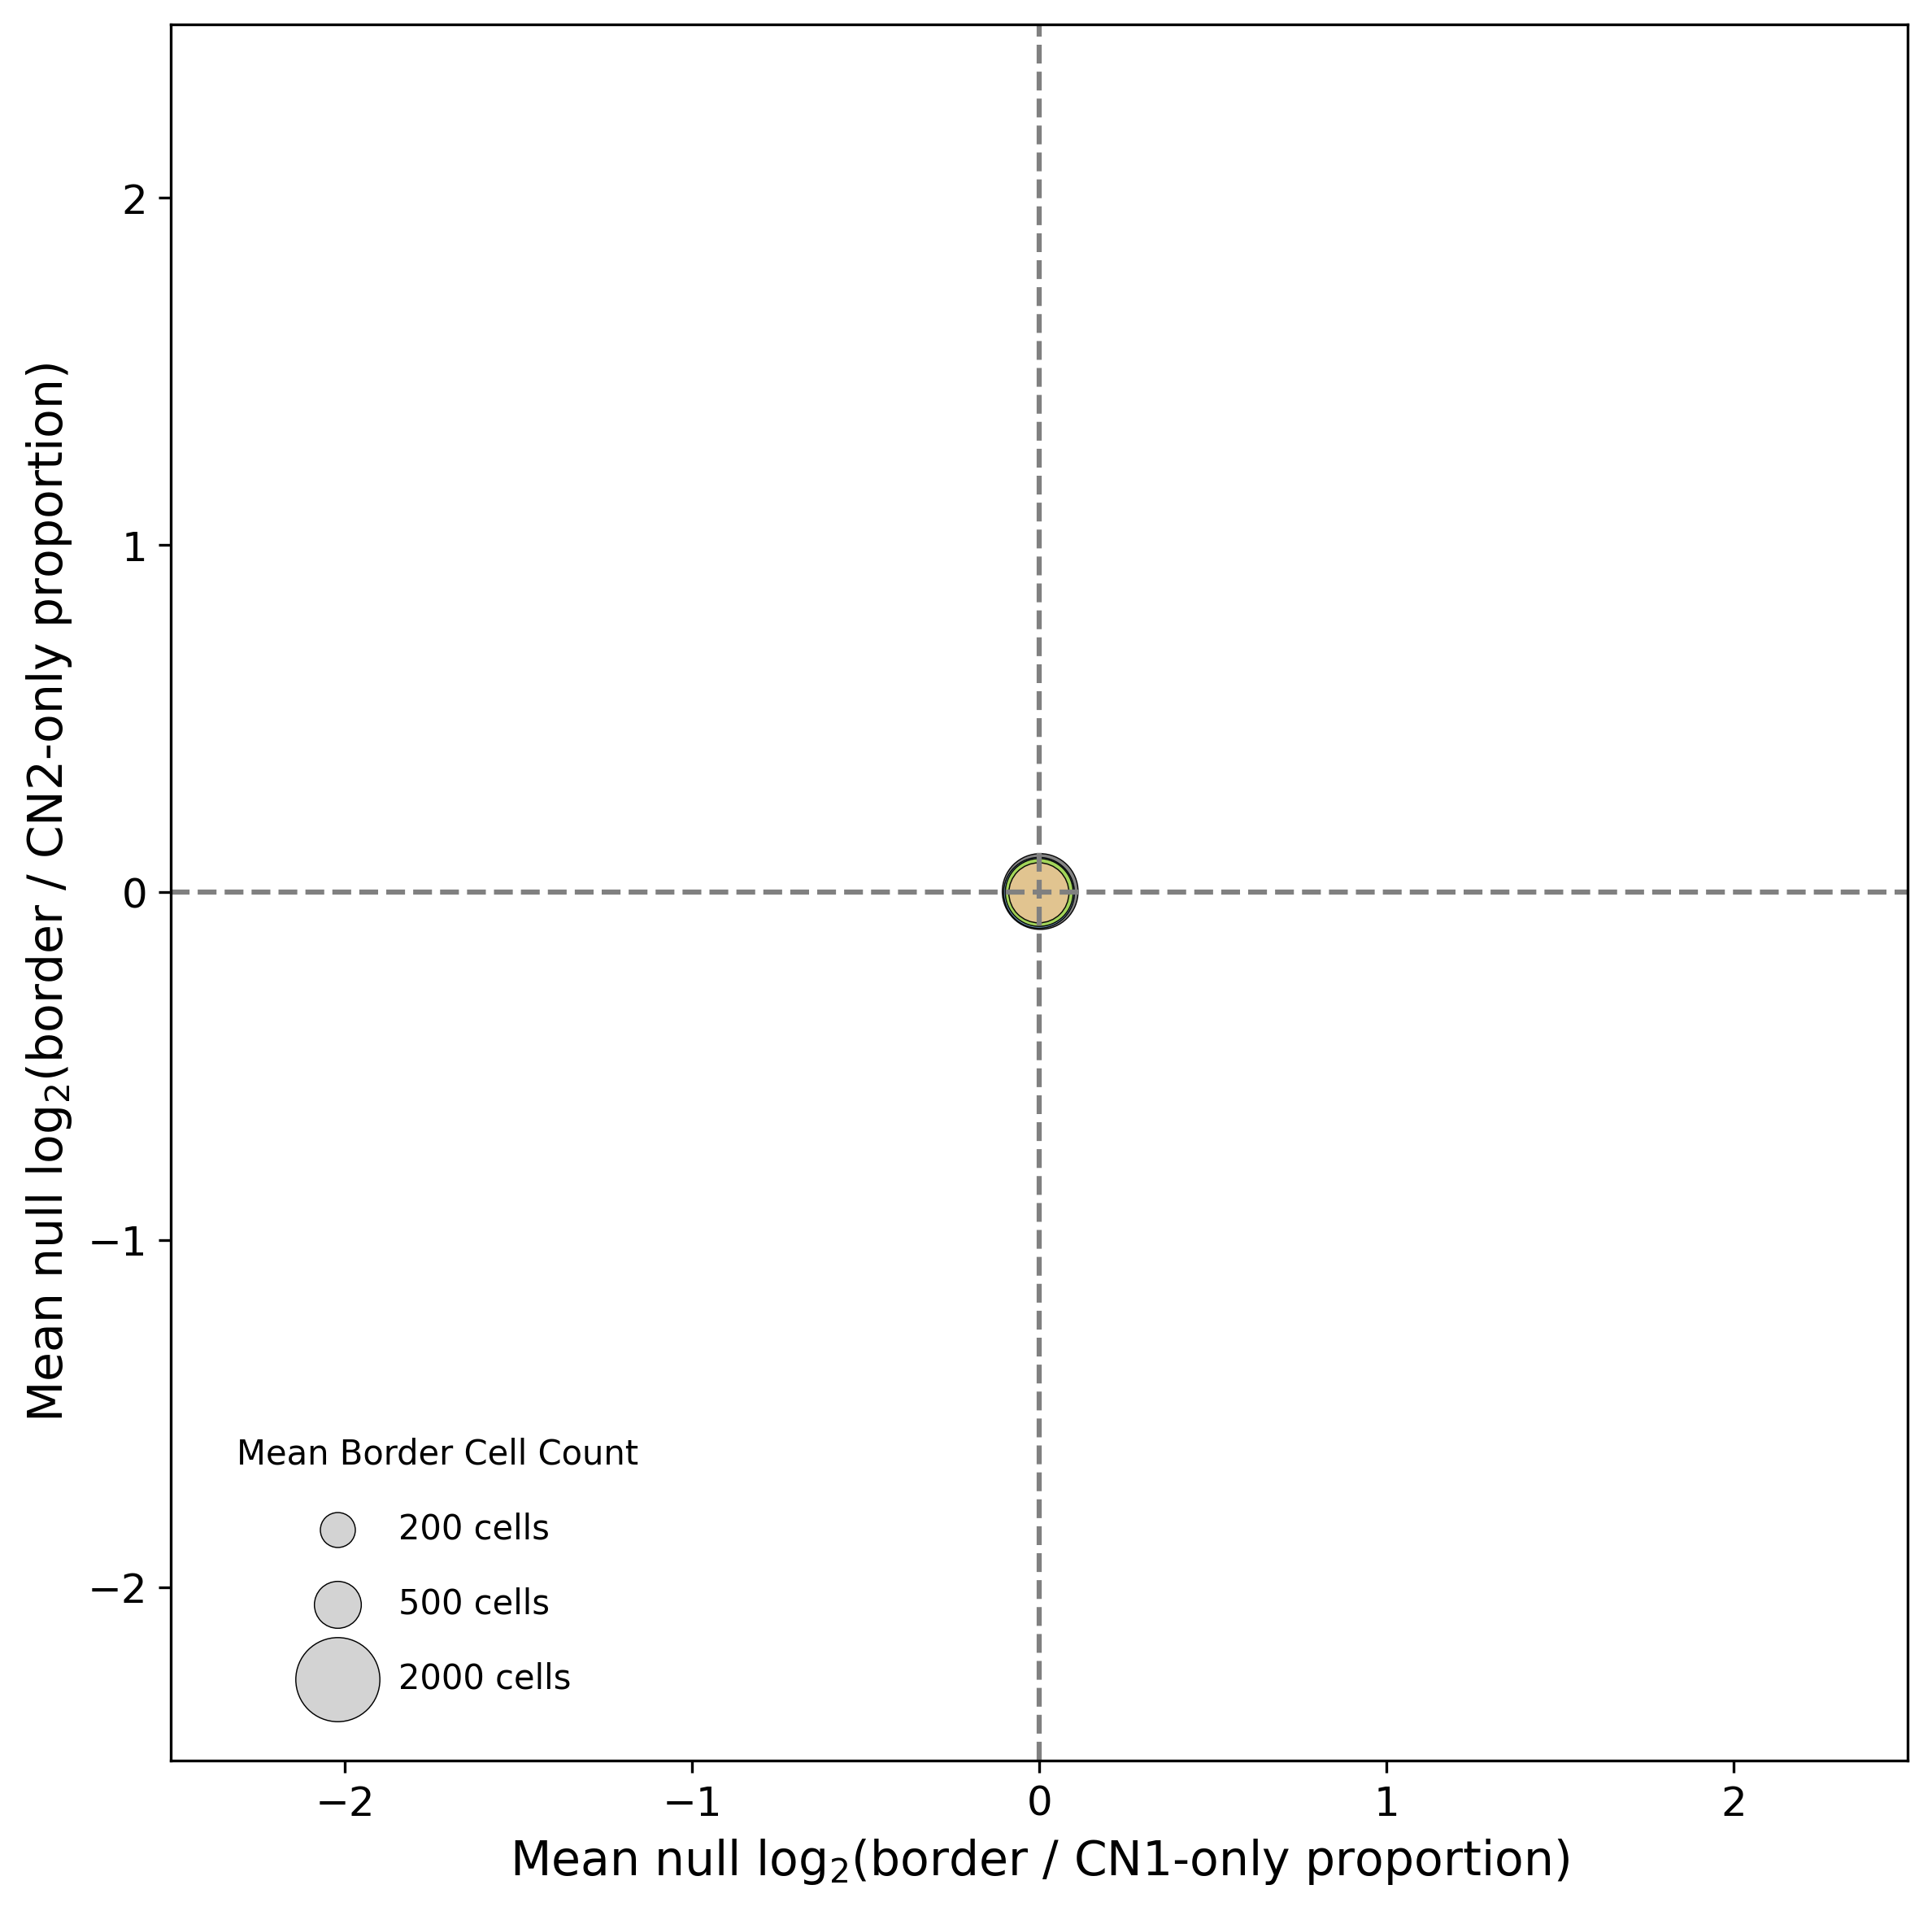

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Mean null enrichment coordinates and mean null border counts
# ------------------------------------------------------------
null_mean_enrichment = (
    null_enrichment
    .groupby("Cell_Type", as_index=False)
    .agg(
        mean_x=("x_border_vs_CN1", "mean"),
        mean_y=("y_border_vs_CN2", "mean"),
        mean_border_count=("Border_count", "mean"),
        sd_x=("x_border_vs_CN1", "std"),
        sd_y=("y_border_vs_CN2", "std"),
    )
)

# Preserve the same cell-type order as the observed plot
null_mean_enrichment["Cell_Type"] = pd.Categorical(
    null_mean_enrichment["Cell_Type"],
    categories=observed_enrichment["Cell_Type"],
    ordered=True,
)

null_mean_enrichment = (
    null_mean_enrichment
    .dropna(subset=["Cell_Type"])
    .sort_values("Cell_Type")
    .reset_index(drop=True)
)

display(null_mean_enrichment)


# ------------------------------------------------------------
# Point colors
#
# Uses your existing color_dict if you already defined one.
# Otherwise, assigns a stable palette for this plot.
# ------------------------------------------------------------
if "color_dict" not in globals():
    palette = sns.color_palette("tab20", n_colors=len(null_mean_enrichment))
    color_dict = dict(
        zip(null_mean_enrichment["Cell_Type"].astype(str), palette)
    )

point_colors = [
    color_dict.get(cell_type, "#cccccc")
    for cell_type in null_mean_enrichment["Cell_Type"].astype(str)
]


# ------------------------------------------------------------
# Point size based on mean number of shuffled border cells
# ------------------------------------------------------------
mean_counts = null_mean_enrichment["mean_border_count"].to_numpy()

point_sizes = 50 + (
    450 * mean_counts / mean_counts.max()
)


# ------------------------------------------------------------
# Plot mean null enrichment
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

ax.scatter(
    null_mean_enrichment["mean_x"],
    null_mean_enrichment["mean_y"],
    s=point_sizes,
    c=point_colors,
    edgecolor="black",
    linewidth=0.35,
    alpha=0.95,
)

ax.axhline(0, color="gray", linestyle="--")
ax.axvline(0, color="gray", linestyle="--")

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect("equal", "box")

ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_yticks([-2, -1, 0, 1, 2])

ax.set_xlabel(
    "Mean null log$_2$(border / CN1-only proportion)",
    fontsize=14,
)
ax.set_ylabel(
    "Mean null log$_2$(border / CN2-only proportion)",
    fontsize=14,
)

ax.tick_params(axis="both", labelsize=12)
ax.grid(False)

# ------------------------------------------------------------
# Dot-size legend: mean shuffled border-cell count
# ------------------------------------------------------------
legend_counts = [200, 500, 2000]

legend_handles = [
    ax.scatter(
        [],
        [],
        s=50 + (450 * count / mean_counts.max()),
        color="lightgray",
        edgecolor="black",
        linewidth=0.35,
        label=f"{count} cells",
    )
    for count in legend_counts
]

ax.legend(
    handles=legend_handles,
    title="Mean Border Cell Count",
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=False,
    scatterpoints=1,
    labelspacing=1.2,
)

plt.tight_layout()
plt.show()